## Template d’Analyse Exploratoire de Données (AED)

Ce notebook sert de point de départ rapide pour les AED.

Sections incluses:
- Imports et configuration
- Chargement des données (Excel, CSV/URL)
- Description du dataset (types, échelles, % manquants)
- Nettoyage (doublons, conversions, renommage de colonnes)
- Analyse de la cible et de son équilibre
- Blocs de statistiques (globales et groupées par cible)
- Visualisations (boxplots vs cible, heatmap avec seuil ajustable)

Paramétrer la cellule « Paramètres » puis exécuter séquentiellement.


In [1]:
# Paramètres
projectName = "SparkleMovie - MovieLens 32M"
randomSeed = 42

# Configuration MovieLens
movieLensUrl = "https://files.grouplens.org/datasets/movielens/ml-32m.zip"
dataDir = "./ml-32m"
zipPath = "./ml-32m.zip"

# Options de chargement
# dataSource peut être "movielens" pour ce projet
dataSource = "movielens"

# Fichiers MovieLens à charger
loadRatings = True
loadMovies = True
loadTags = True
loadLinks = True
loadGenome = False  # Genome files sont volumineux, désactiver par défaut

# Cible et colonnes utiles (pour ratings)
# targetColumn sera utilisée pour l'équilibre des classes et les groupby
targetColumn = "rating"  # pour l'analyse des ratings

# Colonnes numériques/catégorielles (laisser None pour détection auto)
numericColumns = None
categoricalColumns = None

# Paramètres d'affichage
maxRowsToShow = 10
floatPrecision = 4

# Paramètres de visualisation
heatmapCorrThreshold = 0.5  # seuil minimal de corrélation à afficher
figSize = (12, 8)


In [2]:
# Création du requirements.txt (à exécuter avant les imports)
from pathlib import Path

# Liste simple des packages requis pour ce notebook (modifiez selon besoin)
packages = [
    "numpy",
    "pandas",
    "matplotlib",
    "seaborn",
    "scipy",
    "requests",      # téléchargement de fichiers
    "tqdm",          # barres de progression
    "scikit-learn",  # ML éventuel
    "pyspark==3.5.1",       # Spark MLlib pour ALS
]

# Tri + déduplication (sans versions)
requirements = sorted(set(packages), key=lambda x: x.lower())

outPath = Path("requirements.txt")
outPath.write_text("\n".join(requirements), encoding="utf-8")
print(f"requirements.txt écrit: {outPath.resolve()}")
print("Installez ensuite avec: pip install -r requirements.txt")
print("Contenu:\n" + "\n".join(requirements))


requirements.txt écrit: C:\Users\emile\Desktop\Projet Plateforme\SparkleMovie\requirements.txt
Installez ensuite avec: pip install -r requirements.txt
Contenu:
matplotlib
numpy
pandas
pyspark==3.5.1
requests
scikit-learn
scipy
seaborn
tqdm


In [3]:
# Téléchargement et extraction du dataset MovieLens
import os
import zipfile
import requests
from pathlib import Path
from tqdm import tqdm

def downloadFile(url: str, destinationPath: str) -> None:
    """Télécharge un fichier avec barre de progression"""
    if os.path.exists(destinationPath):
        print(f"Fichier déjà téléchargé: {destinationPath}")
        return
    
    print(f"Téléchargement depuis {url}...")
    response = requests.get(url, stream=True)
    response.raise_for_status()
    
    totalSize = int(response.headers.get('content-length', 0))
    blockSize = 8192
    
    with open(destinationPath, 'wb') as file:
        with tqdm(total=totalSize, unit='B', unit_scale=True) as progressBar:
            for chunk in response.iter_content(blockSize):
                file.write(chunk)
                progressBar.update(len(chunk))
    
    print(f"Téléchargement terminé: {destinationPath}")

def extractZip(zipPath: str, extractTo: str) -> None:
    """Extrait un fichier ZIP"""
    if os.path.exists(extractTo):
        print(f"Dossier déjà extrait: {extractTo}")
        return
    
    print(f"Extraction de {zipPath} vers {extractTo}...")
    with zipfile.ZipFile(zipPath, 'r') as zipRef:
        zipRef.extractall(os.path.dirname(extractTo))
    print(f"Extraction terminée: {extractTo}")

# Télécharger et extraire si nécessaire
if dataSource == "movielens":
    downloadFile(movieLensUrl, zipPath)
    extractZip(zipPath, dataDir)
    print(f"Dataset MovieLens prêt dans: {dataDir}")


Fichier déjà téléchargé: ./ml-32m.zip
Dossier déjà extrait: ./ml-32m
Dataset MovieLens prêt dans: ./ml-32m


In [4]:
# Imports et configuration globale
import sys
import math
import warnings
from typing import Optional, List, Tuple, Dict

import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns

from scipy import stats

# Affichage
pd.set_option("display.max_rows", 200)
pd.set_option("display.max_columns", 200)
pd.set_option("display.width", 200)
pd.set_option("display.precision", floatPrecision)

np.random.seed(randomSeed)
warnings.filterwarnings("ignore")

print(f"Projet: {projectName} - seed={randomSeed}")
print(f"Version pandas: {pd.__version__}, numpy: {np.__version__}")


Projet: SparkleMovie - MovieLens 32M - seed=42
Version pandas: 3.0.1, numpy: 2.4.2


In [5]:
# Fonctions de chargement MovieLens
def loadMovieLensData(dataDir: str) -> Dict[str, pd.DataFrame]:
    """Charge les fichiers MovieLens selon les paramètres définis"""
    datasets = {}
    
    if loadRatings:
        ratingsPath = os.path.join(dataDir, "ratings.csv")
        print(f"Chargement de {ratingsPath}...")
        datasets['ratings'] = pd.read_csv(ratingsPath)
        print(f"  Ratings: {datasets['ratings'].shape}")
    
    if loadMovies:
        moviesPath = os.path.join(dataDir, "movies.csv")
        print(f"Chargement de {moviesPath}...")
        datasets['movies'] = pd.read_csv(moviesPath)
        print(f"  Movies: {datasets['movies'].shape}")
    
    if loadTags:
        tagsPath = os.path.join(dataDir, "tags.csv")
        print(f"Chargement de {tagsPath}...")
        datasets['tags'] = pd.read_csv(tagsPath)
        print(f"  Tags: {datasets['tags'].shape}")
    
    if loadLinks:
        linksPath = os.path.join(dataDir, "links.csv")
        print(f"Chargement de {linksPath}...")
        datasets['links'] = pd.read_csv(linksPath)
        print(f"  Links: {datasets['links'].shape}")
    
    if loadGenome:
        genomeScoresPath = os.path.join(dataDir, "genome-scores.csv")
        genomeTagsPath = os.path.join(dataDir, "genome-tags.csv")
        if os.path.exists(genomeScoresPath):
            print(f"Chargement de {genomeScoresPath}...")
            datasets['genomeScores'] = pd.read_csv(genomeScoresPath)
            print(f"  Genome Scores: {datasets['genomeScores'].shape}")
        if os.path.exists(genomeTagsPath):
            print(f"Chargement de {genomeTagsPath}...")
            datasets['genomeTags'] = pd.read_csv(genomeTagsPath)
            print(f"  Genome Tags: {datasets['genomeTags'].shape}")
    
    return datasets

# Chargement effectif des données
try:
    if dataSource == "movielens":
        movielensData = loadMovieLensData(dataDir)
        
        # Dataset principal pour l'analyse: ratings
        df = movielensData.get('ratings', pd.DataFrame())
        
        # Stocker les autres datasets pour référence
        dfMovies = movielensData.get('movies', pd.DataFrame())
        dfTags = movielensData.get('tags', pd.DataFrame())
        dfLinks = movielensData.get('links', pd.DataFrame())
        
        print(f"\nDataset principal (ratings): {df.shape[0]} lignes, {df.shape[1]} colonnes")
        display(df.head(maxRowsToShow))
        
        if not dfMovies.empty:
            print(f"\nAperçu des films (movies):")
            display(dfMovies.head(maxRowsToShow))
    else:
        print("Source de données non reconnue")
        df = pd.DataFrame()
except Exception as e:
    print("Erreur lors du chargement:", e)
    import traceback
    traceback.print_exc()
    df = pd.DataFrame()


Chargement de ./ml-32m\ratings.csv...
  Ratings: (32000204, 4)
Chargement de ./ml-32m\movies.csv...
  Movies: (87585, 3)
Chargement de ./ml-32m\tags.csv...
  Tags: (2000072, 4)
Chargement de ./ml-32m\links.csv...
  Links: (87585, 3)

Dataset principal (ratings): 32000204 lignes, 4 colonnes


,userId,movieId,rating,timestamp
0,1,17,4.0,944249077
1,1,25,1.0,944250228
2,1,29,2.0,943230976
3,1,30,5.0,944249077
4,1,32,5.0,943228858
5,1,34,2.0,943228491
6,1,36,1.0,944249008
7,1,80,5.0,944248943
8,1,110,3.0,943231119
9,1,111,5.0,944249008



Aperçu des films (movies):


,movieId,title,genres
0,1,Toy Story (1995),Adventure|Animation|Children|Comedy|Fantasy
1,2,Jumanji (1995),Adventure|Children|Fantasy
2,3,Grumpier Old Men (1995),Comedy|Romance
3,4,Waiting to Exhale (1995),Comedy|Drama|Romance
4,5,Father of the Bride Part II (1995),Comedy
5,6,Heat (1995),Action|Crime|Thriller
6,7,Sabrina (1995),Comedy|Romance
7,8,Tom and Huck (1995),Adventure|Children
8,9,Sudden Death (1995),Action
9,10,GoldenEye (1995),Action|Adventure|Thriller


In [6]:
# Description du dataset ratings
print("=== Description du dataset ratings ===\n")

assert isinstance(df, pd.DataFrame), "df doit être un DataFrame"

# Informations de base
print(f"Dimensions: {df.shape[0]:,} lignes × {df.shape[1]} colonnes")
print(f"\nColonnes: {list(df.columns)}")

# Types de données
print(f"\nTypes de données:")
display(df.dtypes.to_frame(name="dtype"))

# Statistiques descriptives
print(f"\nStatistiques descriptives:")
display(df.describe())

# Vérification des valeurs manquantes
missingCount = df.isna().sum()
if missingCount.sum() > 0:
    print(f"\nValeurs manquantes:")
    display(missingCount[missingCount > 0].to_frame(name="missing_count"))
else:
    print(f"\n✓ Aucune valeur manquante détectée")

# Vérification des doublons (par userId + movieId)
if 'userId' in df.columns and 'movieId' in df.columns:
    duplicateCount = df.duplicated(subset=['userId', 'movieId']).sum()
    print(f"\nRatings dupliqués (même userId + movieId): {duplicateCount}")
    
    if duplicateCount > 0:
        print("Exemples de doublons:")
        duplicates = df[df.duplicated(subset=['userId', 'movieId'], keep=False)].sort_values(['userId', 'movieId'])
        display(duplicates.head(maxRowsToShow))

# Vérification de l'intégrité avec le dataset movies
if not dfMovies.empty and 'movieId' in df.columns:
    ratedMovies = df['movieId'].unique()
    knownMovies = dfMovies['movieId'].unique()
    
    missingMovies = set(ratedMovies) - set(knownMovies)
    
    print(f"\n=== Intégrité des données ===")
    print(f"Films avec des ratings: {len(ratedMovies):,}")
    print(f"Films dans le catalogue: {len(knownMovies):,}")
    
    if len(missingMovies) > 0:
        print(f"⚠ Films notés mais absents du catalogue: {len(missingMovies)}")
    else:
        print(f"✓ Tous les films notés sont présents dans le catalogue")

# Plage des valeurs
print(f"\n=== Plages de valeurs ===")
if 'rating' in df.columns:
    print(f"Ratings: [{df['rating'].min()}, {df['rating'].max()}]")
if 'userId' in df.columns:
    print(f"UserIds: [{df['userId'].min()}, {df['userId'].max()}]")
if 'movieId' in df.columns:
    print(f"MovieIds: [{df['movieId'].min()}, {df['movieId'].max()}]")


=== Description du dataset ratings ===

Dimensions: 32,000,204 lignes × 4 colonnes

Colonnes: ['userId', 'movieId', 'rating', 'timestamp']

Types de données:


,dtype
userId,int64
movieId,int64
rating,float64
timestamp,int64



Statistiques descriptives:


,userId,movieId,rating,timestamp
count,3.2000e+07,3.2000e+07,3.2000e+07,3.2000e+07
mean,1.0028e+05,2.9319e+04,3.5404e+00,1.2752e+09
std,5.7949e+04,5.0958e+04,1.0590e+00,2.5616e+08
min,1.0000e+00,1.0000e+00,5.0000e-01,7.8965e+08
25%,5.0053e+04,1.2330e+03,3.0000e+00,1.0510e+09
50%,1.0030e+05,3.4520e+03,3.5000e+00,1.2726e+09
75%,1.5045e+05,4.4199e+04,4.0000e+00,1.5032e+09
max,2.0095e+05,2.9276e+05,5.0000e+00,1.6972e+09



✓ Aucune valeur manquante détectée

Ratings dupliqués (même userId + movieId): 0

=== Intégrité des données ===
Films avec des ratings: 84,432
Films dans le catalogue: 87,585
✓ Tous les films notés sont présents dans le catalogue

=== Plages de valeurs ===
Ratings: [0.5, 5.0]
UserIds: [1, 200948]
MovieIds: [1, 292757]


In [7]:
# Préparation et enrichissement des données MovieLens
# Conversion du timestamp en datetime
if 'timestamp' in df.columns:
    df['datetime'] = pd.to_datetime(df['timestamp'], unit='s')
    df['year'] = df['datetime'].dt.year
    df['month'] = df['datetime'].dt.month
    df['dayOfWeek'] = df['datetime'].dt.dayofweek
    df['hour'] = df['datetime'].dt.hour
    print("Colonnes temporelles ajoutées: datetime, year, month, dayOfWeek, hour")

# Extraire l'année de sortie des films depuis le titre (format: "Title (YYYY)")
if not dfMovies.empty and 'title' in dfMovies.columns:
    dfMovies['releaseYear'] = dfMovies['title'].str.extract(r'\((\d{4})\)').astype('Int64')
    print(f"Année de sortie extraite pour {dfMovies['releaseYear'].notna().sum()} films")

# Statistiques de base sur les datasets
print(f"\n=== Statistiques des datasets ===")
print(f"Nombre total de ratings: {len(df):,}")
if not dfMovies.empty:
    print(f"Nombre total de films: {len(dfMovies):,}")
if not dfTags.empty:
    print(f"Nombre total de tags: {len(dfTags):,}")

if not df.empty:
    print(f"Nombre d'utilisateurs uniques: {df['userId'].nunique():,}")
    print(f"Nombre de films notés: {df['movieId'].nunique():,}")
    print(f"Période des ratings: {df['datetime'].min()} à {df['datetime'].max()}")


Colonnes temporelles ajoutées: datetime, year, month, dayOfWeek, hour
Année de sortie extraite pour 86970 films

=== Statistiques des datasets ===
Nombre total de ratings: 32,000,204
Nombre total de films: 87,585
Nombre total de tags: 2,000,072
Nombre d'utilisateurs uniques: 200,948
Nombre de films notés: 84,432
Période des ratings: 1995-01-09 11:46:44 à 2023-10-13 02:29:07


=== Distribution des ratings ===

Statistiques des ratings:
  Moyenne: 3.5404
  Médiane: 3.5000
  Écart-type: 1.0590
  Min: 0.5
  Max: 5.0

Distribution des notes:


,count,percentage
rating,,
0.5,525132,1.6410
1.0,946675,2.9583
1.5,531063,1.6596
2.0,2028622,6.3394
2.5,1685386,5.2668
3.0,6054990,18.9217
3.5,4290105,13.4065
4.0,8367654,26.1488
4.5,2974000,9.2937


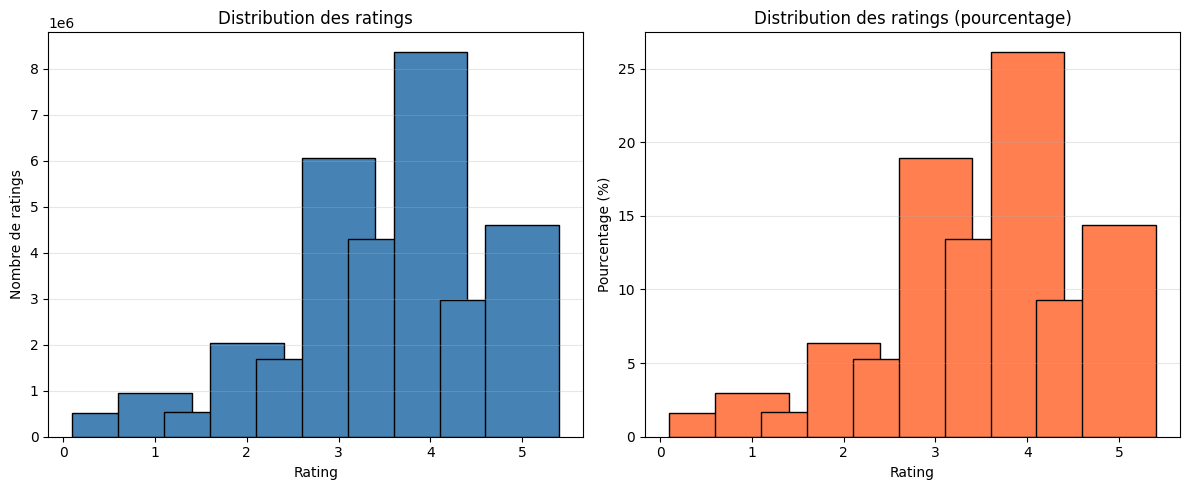

In [8]:
# Analyse de la distribution des ratings
if targetColumn is None or targetColumn not in df.columns:
    print("Définissez targetColumn pour activer l'analyse de la cible.")
else:
    targetSeries = df[targetColumn]
    print("=== Distribution des ratings ===")
    
    # Statistiques descriptives des ratings
    print(f"\nStatistiques des ratings:")
    print(f"  Moyenne: {targetSeries.mean():.4f}")
    print(f"  Médiane: {targetSeries.median():.4f}")
    print(f"  Écart-type: {targetSeries.std():.4f}")
    print(f"  Min: {targetSeries.min():.1f}")
    print(f"  Max: {targetSeries.max():.1f}")
    
    # Distribution des notes
    print(f"\nDistribution des notes:")
    ratingCounts = targetSeries.value_counts().sort_index()
    ratingPcts = (ratingCounts / len(df) * 100)
    
    distTable = pd.DataFrame({
        'count': ratingCounts,
        'percentage': ratingPcts
    })
    display(distTable)
    
    # Visualisation de la distribution
    plt.figure(figsize=(12, 5))
    
    plt.subplot(1, 2, 1)
    plt.bar(ratingCounts.index, ratingCounts.values, color='steelblue', edgecolor='black')
    plt.xlabel('Rating')
    plt.ylabel('Nombre de ratings')
    plt.title('Distribution des ratings')
    plt.grid(axis='y', alpha=0.3)
    
    plt.subplot(1, 2, 2)
    plt.bar(ratingPcts.index, ratingPcts.values, color='coral', edgecolor='black')
    plt.xlabel('Rating')
    plt.ylabel('Pourcentage (%)')
    plt.title('Distribution des ratings (pourcentage)')
    plt.grid(axis='y', alpha=0.3)
    
    plt.tight_layout()
    plt.show()


In [9]:
# Analyses spécifiques MovieLens

# 1. Statistiques par utilisateur
print("=== Statistiques par utilisateur ===")
userStats = df.groupby('userId').agg({
    'rating': ['count', 'mean', 'std'],
    'movieId': 'nunique'
}).round(4)
userStats.columns = ['nbRatings', 'avgRating', 'stdRating', 'nbMovies']

print(f"\nStatistiques sur les utilisateurs:")
print(f"  Nombre moyen de ratings par utilisateur: {userStats['nbRatings'].mean():.2f}")
print(f"  Médiane de ratings par utilisateur: {userStats['nbRatings'].median():.2f}")
print(f"  Min ratings par utilisateur: {userStats['nbRatings'].min()}")
print(f"  Max ratings par utilisateur: {userStats['nbRatings'].max()}")

print(f"\nTop 10 utilisateurs les plus actifs:")
display(userStats.nlargest(10, 'nbRatings'))

# 2. Statistiques par film
print("\n=== Statistiques par film ===")
movieStats = df.groupby('movieId').agg({
    'rating': ['count', 'mean', 'std'],
    'userId': 'nunique'
}).round(4)
movieStats.columns = ['nbRatings', 'avgRating', 'stdRating', 'nbUsers']

print(f"\nStatistiques sur les films:")
print(f"  Nombre moyen de ratings par film: {movieStats['nbRatings'].mean():.2f}")
print(f"  Médiane de ratings par film: {movieStats['nbRatings'].median():.2f}")
print(f"  Min ratings par film: {movieStats['nbRatings'].min()}")
print(f"  Max ratings par film: {movieStats['nbRatings'].max()}")

# Joindre avec les informations des films
if not dfMovies.empty:
    movieStatsWithTitles = movieStats.merge(
        dfMovies[['movieId', 'title']], 
        left_index=True, 
        right_on='movieId'
    )
    
    print(f"\nTop 10 films les plus notés:")
    display(movieStatsWithTitles.nlargest(10, 'nbRatings')[['title', 'nbRatings', 'avgRating', 'stdRating']])
    
    print(f"\nTop 10 films avec les meilleures notes moyennes (min 1000 ratings):")
    popularMovies = movieStatsWithTitles[movieStatsWithTitles['nbRatings'] >= 1000]
    display(popularMovies.nlargest(10, 'avgRating')[['title', 'nbRatings', 'avgRating', 'stdRating']])

# 3. Évolution temporelle des ratings
print("\n=== Évolution temporelle ===")
if 'year' in df.columns:
    ratingsByYear = df.groupby('year').agg({
        'rating': ['count', 'mean']
    }).round(4)
    ratingsByYear.columns = ['nbRatings', 'avgRating']
    
    print(f"\nRatings par année:")
    display(ratingsByYear.tail(10))


=== Statistiques par utilisateur ===

Statistiques sur les utilisateurs:
  Nombre moyen de ratings par utilisateur: 159.25
  Médiane de ratings par utilisateur: 73.00
  Min ratings par utilisateur: 20
  Max ratings par utilisateur: 33332

Top 10 utilisateurs les plus actifs:


,nbRatings,avgRating,stdRating,nbMovies
userId,,,,
175325,33332,3.0778,0.7429,33332
17035,9577,2.5678,1.0429,9577
55653,9178,3.2803,0.5602,9178
123465,9044,2.5289,1.2678,9044
171795,9016,3.1820,0.5225,9016
10202,7748,3.4117,0.9846,7748
198515,7594,2.8228,0.9301,7594
49305,7488,3.2089,0.9479,7488
22744,7372,2.6402,1.2019,7372



=== Statistiques par film ===

Statistiques sur les films:
  Nombre moyen de ratings par film: 379.01
  Médiane de ratings par film: 5.00
  Min ratings par film: 1
  Max ratings par film: 102929

Top 10 films les plus notés:


,title,nbRatings,avgRating,stdRating
314,"Shawshank Redemption, The (1994)",102929,4.4046,0.7661
351,Forrest Gump (1994),100296,4.0527,0.9352
292,Pulp Fiction (1994),98409,4.1970,0.9456
2480,"Matrix, The (1999)",93808,4.1564,0.9072
585,"Silence of the Lambs, The (1991)",90330,4.1484,0.8629
257,Star Wars: Episode IV - A New Hope (1977),85010,4.0998,0.9930
2867,Fight Club (1999),77332,4.2288,0.8604
475,Jurassic Park (1993),75233,3.6986,0.9373
522,Schindler's List (1993),73849,4.2370,0.8833
4888,"Lord of the Rings: The Fellowship of the Ring,...",73122,4.0921,1.0093



Top 10 films avec les meilleures notes moyennes (min 1000 ratings):


,title,nbRatings,avgRating,stdRating
46252,Planet Earth II (2016),1956,4.4468,0.8162
40985,Planet Earth (2006),2948,4.4444,0.7644
46103,Band of Brothers (2001),2811,4.4265,0.7687
314,"Shawshank Redemption, The (1994)",102929,4.4046,0.7661
840,"Godfather, The (1972)",66440,4.3170,0.8752
61090,Parasite (2019),11670,4.3123,0.7748
50126,Blue Planet II (2017),1163,4.3001,0.9227
59131,Twin Peaks (1989),1140,4.2987,0.8747
1173,12 Angry Men (1957),21863,4.2653,0.7777
49,"Usual Suspects, The (1995)",67750,4.2651,0.7932



=== Évolution temporelle ===

Ratings par année:


,nbRatings,avgRating
year,,
2014,518537,3.6116
2015,1743866,3.5593
2016,1918739,3.5364
2017,1827953,3.5484
2018,1391057,3.5707
2019,1385467,3.5789
2020,1688159,3.5988
2021,1239912,3.5828
2022,913105,3.4997


=== Analyse des genres ===

Nombre total de genres: 20

Distribution des genres:


,genre,count
6,Drama,34175
3,Comedy,23124
9,Thriller,11823
5,Romance,10369
7,Action,9668
14,Documentary,9363
10,Horror,8654
19,(no genres listed),7080
8,Crime,6976
0,Adventure,5402


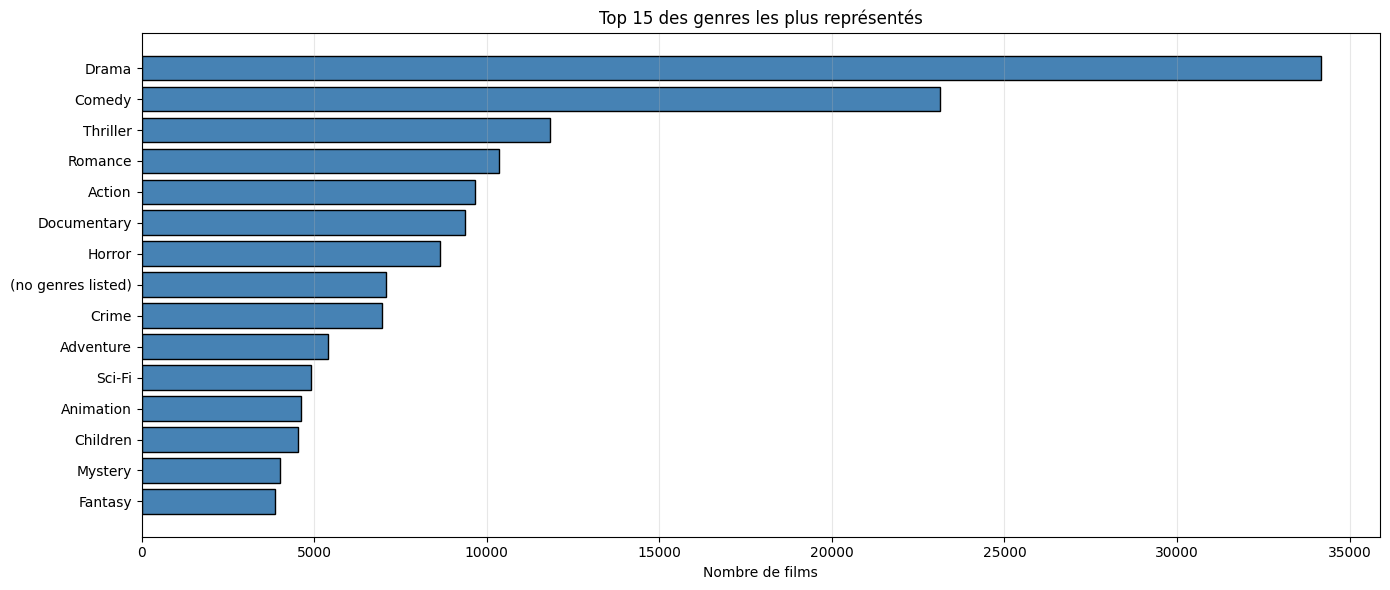


Statistiques des ratings par genre:


,nbRatings,avgRating,stdRating
genres,,,
Drama,13973271,3.6825,0.9962
Comedy,11206926,3.4324,1.0818
Action,9665213,3.4764,1.0702
Thriller,8679464,3.5317,1.0351
Adventure,7590522,3.5234,1.0691
Sci-Fi,5717337,3.4917,1.0835
Romance,5524615,3.5450,1.0487
Crime,5373051,3.6918,1.0058
Fantasy,3702759,3.5122,1.0903


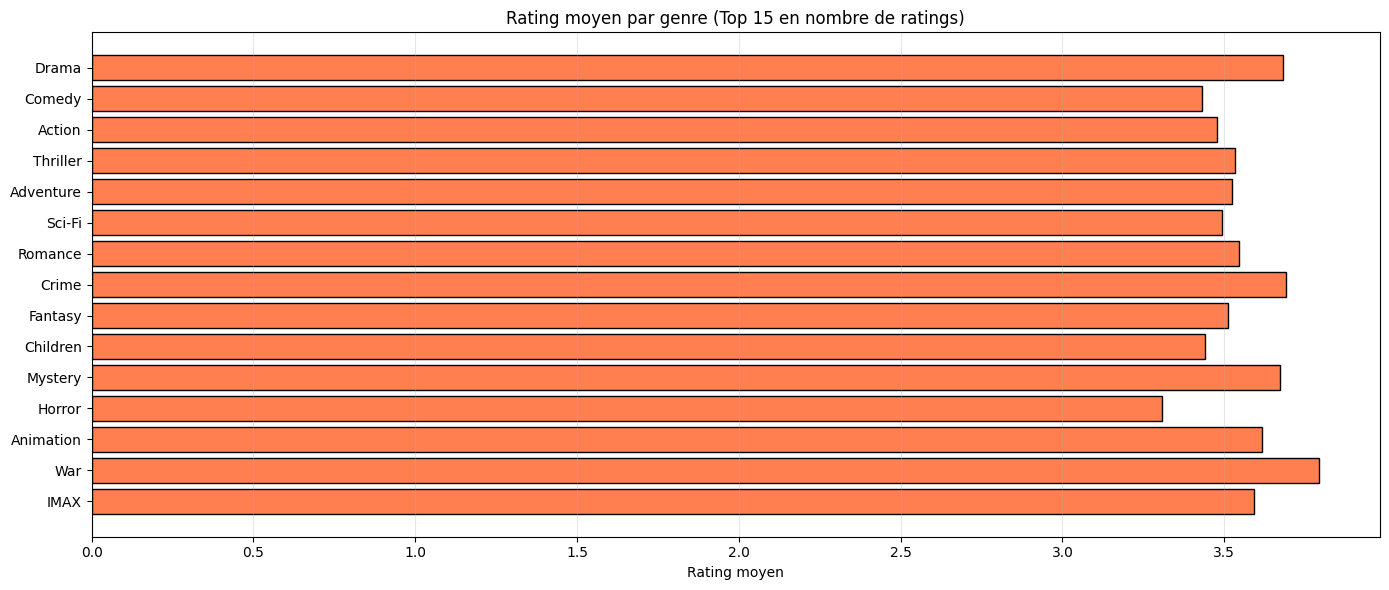

=== Visualisations temporelles ===


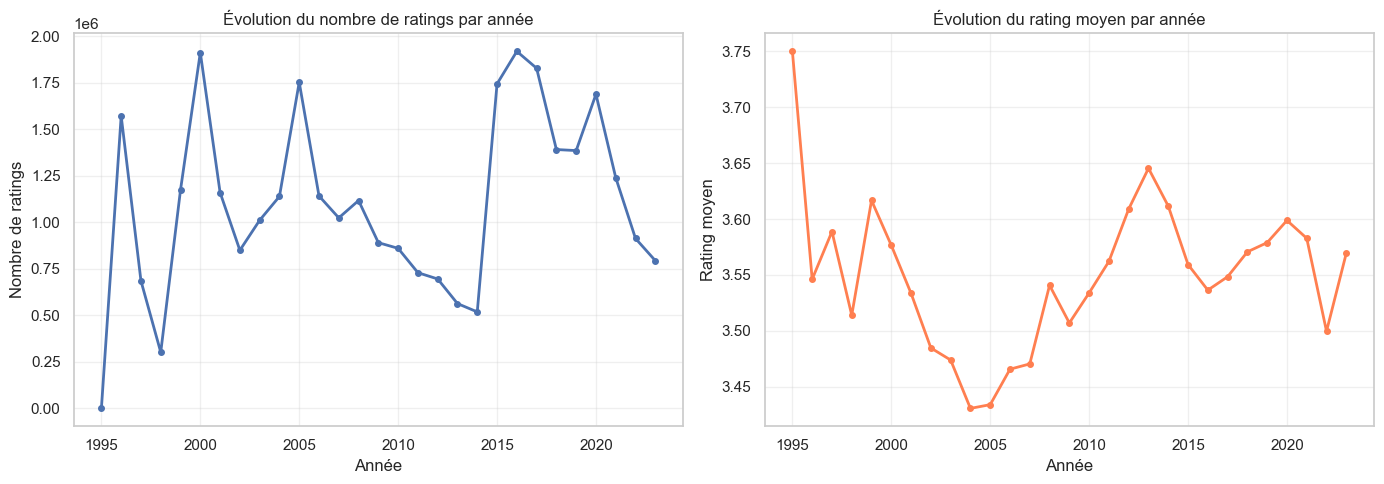

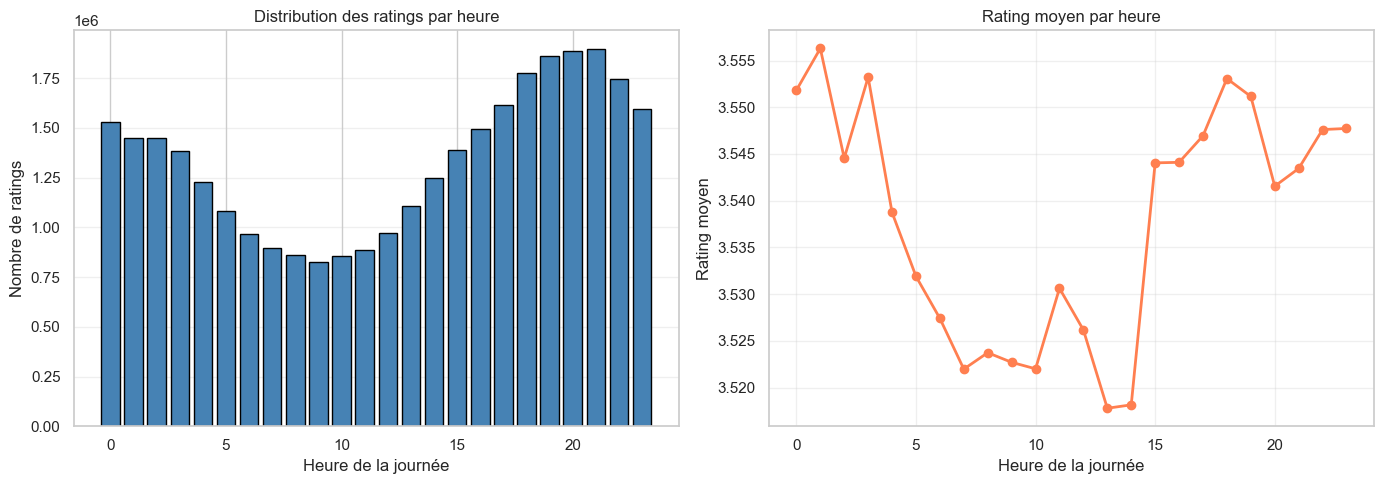

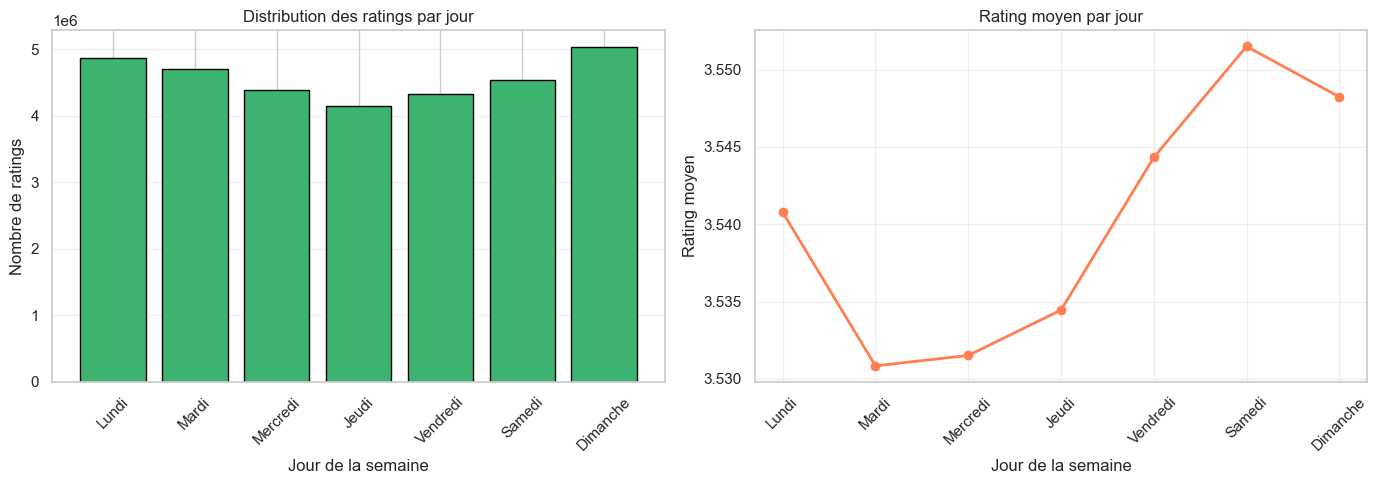


=== Distribution de l'activité ===


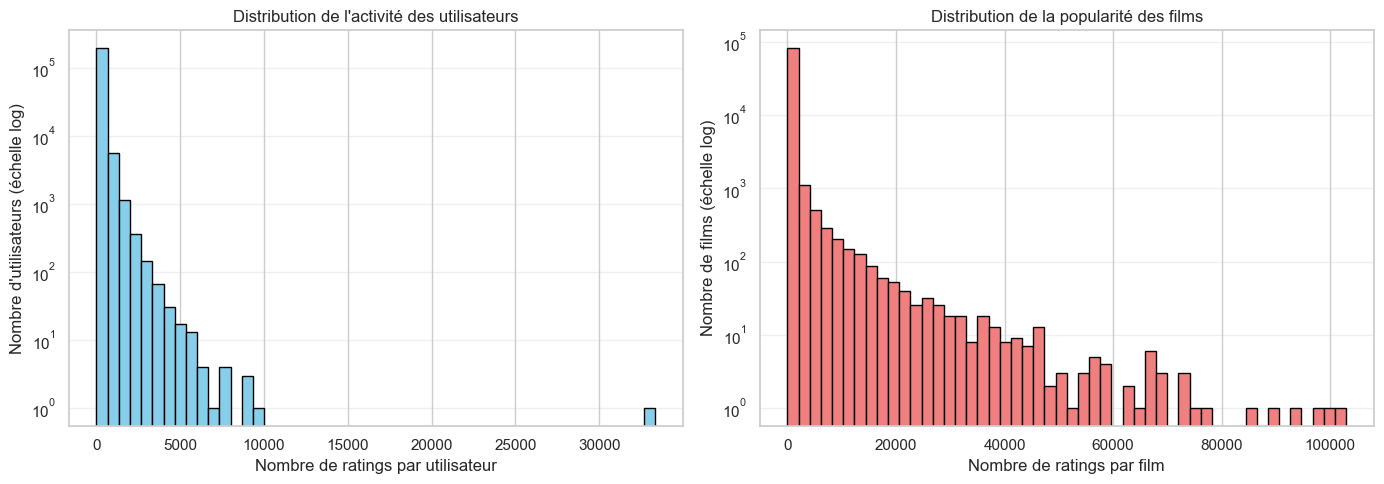


Visualisations terminées!


In [10]:
# Analyse des genres de films
if not dfMovies.empty and 'genres' in dfMovies.columns:
    print("=== Analyse des genres ===")
    
    # Extraire tous les genres uniques
    allGenres = []
    for genres in dfMovies['genres'].dropna():
        allGenres.extend(genres.split('|'))
    
    from collections import Counter
    genreCounts = Counter(allGenres)
    
    # Créer un DataFrame des genres
    genresDF = pd.DataFrame(list(genreCounts.items()), columns=['genre', 'count']).sort_values('count', ascending=False)
    
    print(f"\nNombre total de genres: {len(genresDF)}")
    print(f"\nDistribution des genres:")
    display(genresDF)
    
    # Visualisation des genres les plus populaires
    plt.figure(figsize=(14, 6))
    
    topGenres = genresDF.head(15)
    plt.barh(range(len(topGenres)), topGenres['count'].values, color='steelblue', edgecolor='black')
    plt.yticks(range(len(topGenres)), topGenres['genre'].values)
    plt.xlabel('Nombre de films')
    plt.title('Top 15 des genres les plus représentés')
    plt.gca().invert_yaxis()
    plt.grid(axis='x', alpha=0.3)
    plt.tight_layout()
    plt.show()
    
    # Analyse des ratings par genre
    # Créer une version étendue avec un film par ligne et par genre
    moviesExploded = dfMovies.copy()
    moviesExploded['genres'] = moviesExploded['genres'].str.split('|')
    moviesExploded = moviesExploded.explode('genres')
    
    # Joindre avec les ratings
    ratingsWithGenres = df.merge(moviesExploded[['movieId', 'genres']], on='movieId', how='left')
    
    # Statistiques par genre
    genreStats = ratingsWithGenres.groupby('genres').agg({
        'rating': ['count', 'mean', 'std']
    }).round(4)
    genreStats.columns = ['nbRatings', 'avgRating', 'stdRating']
    genreStats = genreStats.sort_values('nbRatings', ascending=False)
    
    print(f"\nStatistiques des ratings par genre:")
    display(genreStats)
    
    # Visualisation des ratings moyens par genre
    plt.figure(figsize=(14, 6))
    
    topGenresRatings = genreStats.head(15)
    plt.barh(range(len(topGenresRatings)), topGenresRatings['avgRating'].values, 
             color='coral', edgecolor='black')
    plt.yticks(range(len(topGenresRatings)), topGenresRatings.index)
    plt.xlabel('Rating moyen')
    plt.title('Rating moyen par genre (Top 15 en nombre de ratings)')
    plt.gca().invert_yaxis()
    plt.grid(axis='x', alpha=0.3)
    plt.tight_layout()
    plt.show()

# Visualisations avancées MovieLens
sns.set(style="whitegrid")

# 1. Évolution temporelle des ratings
if 'year' in df.columns and 'month' in df.columns:
    print("=== Visualisations temporelles ===")
    
    # Nombre de ratings par année
    plt.figure(figsize=(14, 5))
    
    plt.subplot(1, 2, 1)
    yearlyRatings = df.groupby('year')['rating'].count()
    plt.plot(yearlyRatings.index, yearlyRatings.values, marker='o', linewidth=2, markersize=4)
    plt.xlabel('Année')
    plt.ylabel('Nombre de ratings')
    plt.title('Évolution du nombre de ratings par année')
    plt.grid(True, alpha=0.3)
    
    # Note moyenne par année
    plt.subplot(1, 2, 2)
    yearlyAvg = df.groupby('year')['rating'].mean()
    plt.plot(yearlyAvg.index, yearlyAvg.values, marker='o', linewidth=2, markersize=4, color='coral')
    plt.xlabel('Année')
    plt.ylabel('Rating moyen')
    plt.title('Évolution du rating moyen par année')
    plt.grid(True, alpha=0.3)
    
    plt.tight_layout()
    plt.show()

# 2. Distribution des ratings par heure de la journée
if 'hour' in df.columns:
    plt.figure(figsize=(14, 5))
    
    plt.subplot(1, 2, 1)
    hourlyRatings = df.groupby('hour')['rating'].count()
    plt.bar(hourlyRatings.index, hourlyRatings.values, color='steelblue', edgecolor='black')
    plt.xlabel('Heure de la journée')
    plt.ylabel('Nombre de ratings')
    plt.title('Distribution des ratings par heure')
    plt.grid(axis='y', alpha=0.3)
    
    plt.subplot(1, 2, 2)
    hourlyAvg = df.groupby('hour')['rating'].mean()
    plt.plot(hourlyAvg.index, hourlyAvg.values, marker='o', linewidth=2, markersize=6, color='coral')
    plt.xlabel('Heure de la journée')
    plt.ylabel('Rating moyen')
    plt.title('Rating moyen par heure')
    plt.grid(True, alpha=0.3)
    
    plt.tight_layout()
    plt.show()

# 3. Distribution des ratings par jour de la semaine
if 'dayOfWeek' in df.columns:
    plt.figure(figsize=(14, 5))
    
    daysNames = ['Lundi', 'Mardi', 'Mercredi', 'Jeudi', 'Vendredi', 'Samedi', 'Dimanche']
    
    plt.subplot(1, 2, 1)
    dayRatings = df.groupby('dayOfWeek')['rating'].count()
    plt.bar(range(7), [dayRatings.get(i, 0) for i in range(7)], 
            color='mediumseagreen', edgecolor='black')
    plt.xticks(range(7), daysNames, rotation=45)
    plt.xlabel('Jour de la semaine')
    plt.ylabel('Nombre de ratings')
    plt.title('Distribution des ratings par jour')
    plt.grid(axis='y', alpha=0.3)
    
    plt.subplot(1, 2, 2)
    dayAvg = df.groupby('dayOfWeek')['rating'].mean()
    plt.plot(range(7), [dayAvg.get(i, 0) for i in range(7)], 
             marker='o', linewidth=2, markersize=6, color='coral')
    plt.xticks(range(7), daysNames, rotation=45)
    plt.xlabel('Jour de la semaine')
    plt.ylabel('Rating moyen')
    plt.title('Rating moyen par jour')
    plt.grid(True, alpha=0.3)
    
    plt.tight_layout()
    plt.show()

# 4. Distribution de l'activité des utilisateurs
print("\n=== Distribution de l'activité ===")
if 'userId' in df.columns:
    userActivityCounts = df.groupby('userId').size()
    
    plt.figure(figsize=(14, 5))
    
    plt.subplot(1, 2, 1)
    plt.hist(userActivityCounts, bins=50, color='skyblue', edgecolor='black', log=True)
    plt.xlabel('Nombre de ratings par utilisateur')
    plt.ylabel('Nombre d\'utilisateurs (échelle log)')
    plt.title('Distribution de l\'activité des utilisateurs')
    plt.grid(axis='y', alpha=0.3)
    
    plt.subplot(1, 2, 2)
    movieRatingCounts = df.groupby('movieId').size()
    plt.hist(movieRatingCounts, bins=50, color='lightcoral', edgecolor='black', log=True)
    plt.xlabel('Nombre de ratings par film')
    plt.ylabel('Nombre de films (échelle log)')
    plt.title('Distribution de la popularité des films')
    plt.grid(axis='y', alpha=0.3)
    
    plt.tight_layout()
    plt.show()

print("\nVisualisations terminées!")


In [11]:
# Analyses supplémentaires et insights

print("=== Analyses supplémentaires ===\n")

# 1. Matrice de similarité utilisateur-utilisateur (échantillon)
print("1. Analyse de similarité (échantillon)")
if not df.empty and len(df) > 0:
    # Prendre un échantillon d'utilisateurs actifs
    topUsers = df.groupby('userId').size().nlargest(100).index
    dfSample = df[df['userId'].isin(topUsers)]
    
    # Créer une matrice utilisateur-film (échantillon)
    userMovieMatrix = dfSample.pivot_table(
        index='userId', 
        columns='movieId', 
        values='rating'
    )
    
    print(f"  Matrice échantillon: {userMovieMatrix.shape[0]} utilisateurs × {userMovieMatrix.shape[1]} films")
    print(f"  Densité de la matrice: {(userMovieMatrix.notna().sum().sum() / userMovieMatrix.size * 100):.2f}%")

# 2. Analyse des biais de notation
print("\n2. Analyse des biais de notation")
if 'userId' in df.columns:
    # Calcul du biais par utilisateur (différence avec la moyenne globale)
    globalMean = df['rating'].mean()
    userBias = df.groupby('userId')['rating'].mean() - globalMean
    
    print(f"  Moyenne globale des ratings: {globalMean:.4f}")
    print(f"  Biais moyen par utilisateur: {userBias.mean():.4f}")
    print(f"  Écart-type du biais: {userBias.std():.4f}")
    print(f"  Utilisateurs avec biais positif: {(userBias > 0).sum()} ({(userBias > 0).sum() / len(userBias) * 100:.1f}%)")
    print(f"  Utilisateurs avec biais négatif: {(userBias < 0).sum()} ({(userBias < 0).sum() / len(userBias) * 100:.1f}%)")

# 3. Analyse de la longue traîne (Long Tail)
print("\n3. Analyse de la longue traîne")
if 'movieId' in df.columns:
    moviePopularity = df.groupby('movieId').size().sort_values(ascending=False)
    
    # Calculer la distribution
    top1Pct = int(len(moviePopularity) * 0.01)
    top5Pct = int(len(moviePopularity) * 0.05)
    top10Pct = int(len(moviePopularity) * 0.10)
    
    ratingsTop1 = moviePopularity.head(top1Pct).sum()
    ratingsTop5 = moviePopularity.head(top5Pct).sum()
    ratingsTop10 = moviePopularity.head(top10Pct).sum()
    totalRatings = moviePopularity.sum()
    
    print(f"  Top 1% des films ({top1Pct} films): {ratingsTop1:,} ratings ({ratingsTop1/totalRatings*100:.1f}%)")
    print(f"  Top 5% des films ({top5Pct} films): {ratingsTop5:,} ratings ({ratingsTop5/totalRatings*100:.1f}%)")
    print(f"  Top 10% des films ({top10Pct} films): {ratingsTop10:,} ratings ({ratingsTop10/totalRatings*100:.1f}%)")

# 4. Films controversés (fort écart-type)
print("\n4. Films les plus controversés (forte variance dans les ratings)")
if not df.empty and not dfMovies.empty:
    movieStdDev = df.groupby('movieId').agg({
        'rating': ['std', 'mean', 'count']
    })
    movieStdDev.columns = ['stdRating', 'avgRating', 'nbRatings']
    
    # Filtrer les films avec au moins 100 ratings
    controversialMovies = movieStdDev[movieStdDev['nbRatings'] >= 100].sort_values('stdRating', ascending=False)
    
    # Joindre avec les titres
    controversialWithTitles = controversialMovies.merge(
        dfMovies[['movieId', 'title']], 
        left_index=True, 
        right_on='movieId'
    )
    
    print(f"\nTop 10 films les plus controversés (min 100 ratings):")
    display(controversialWithTitles.head(10)[['title', 'avgRating', 'stdRating', 'nbRatings']])

# 5. Recommendations simples basées sur la popularité
print("\n5. Films recommandés (approche simple par popularité et note)")
if not df.empty and not dfMovies.empty:
    # Films avec au moins 500 ratings et note moyenne élevée
    movieQuality = df.groupby('movieId').agg({
        'rating': ['mean', 'count']
    })
    movieQuality.columns = ['avgRating', 'nbRatings']
    
    # Score pondéré (moyenne bayésienne simplifiée)
    minRatings = 500
    C = df['rating'].mean()  # moyenne globale
    
    qualityMovies = movieQuality[movieQuality['nbRatings'] >= minRatings].copy()
    qualityMovies['weightedScore'] = (
        (qualityMovies['nbRatings'] * qualityMovies['avgRating'] + minRatings * C) / 
        (qualityMovies['nbRatings'] + minRatings)
    )
    
    topRecommended = qualityMovies.sort_values('weightedScore', ascending=False).head(20)
    
    # Joindre avec les titres
    recommendedWithTitles = topRecommended.merge(
        dfMovies[['movieId', 'title', 'genres']], 
        left_index=True, 
        right_on='movieId'
    )
    
    print(f"\nTop 20 films recommandés (score pondéré, min {minRatings} ratings):")
    display(recommendedWithTitles[['title', 'genres', 'avgRating', 'nbRatings', 'weightedScore']])

print("\n=== Analyses terminées ===")

=== Analyses supplémentaires ===

1. Analyse de similarité (échantillon)
  Matrice échantillon: 100 utilisateurs × 58855 films
  Densité de la matrice: 8.87%

2. Analyse des biais de notation
  Moyenne globale des ratings: 3.5404
  Biais moyen par utilisateur: 0.1640
  Écart-type du biais: 0.4866
  Utilisateurs avec biais positif: 132409 (65.9%)
  Utilisateurs avec biais négatif: 68539 (34.1%)

3. Analyse de la longue traîne
  Top 1% des films (844 films): 17,551,994 ratings (54.8%)
  Top 5% des films (4221 films): 28,345,173 ratings (88.6%)
  Top 10% des films (8443 films): 30,625,204 ratings (95.7%)

4. Films les plus controversés (forte variance dans les ratings)

Top 10 films les plus controversés (min 100 ratings):


,title,avgRating,stdRating,nbRatings
1277,Santa with Muscles (1996),2.5521,1.7075,163
14392,"Room, The (2003)",2.4822,1.6428,1179
21478,God's Not Dead (2014),2.4108,1.6277,241
12322,Expelled: No Intelligence Allowed (2008),2.0964,1.5963,166
11344,"Secret, The (2006)",2.3186,1.5738,204
1382,Grateful Dead (1995),3.0421,1.5654,190
29196,Barbie as The Princess & the Pauper (2004),3.2817,1.5419,142
1347,Adrenalin: Fear the Rush (1996),2.2517,1.5264,149
52263,Fifty Shades Freed (2018),2.4987,1.5206,394
13101,Tyler Perry's Madea Goes to Jail (2009),2.5634,1.5134,142



5. Films recommandés (approche simple par popularité et note)

Top 20 films recommandés (score pondéré, min 500 ratings):


,title,genres,avgRating,nbRatings,weightedScore
314,"Shawshank Redemption, The (1994)",Crime|Drama,4.4046,102929,4.4004
40985,Planet Earth (2006),Documentary,4.4444,2948,4.3133
840,"Godfather, The (1972)",Crime|Drama,4.3170,66440,4.3112
46103,Band of Brothers (2001),Action|Drama|War,4.4265,2811,4.2927
61090,Parasite (2019),Comedy|Drama,4.3123,11670,4.2805
46252,Planet Earth II (2016),Documentary,4.4468,1956,4.2623
49,"Usual Suspects, The (1995)",Crime|Mystery|Thriller,4.2651,67750,4.2598
1190,"Godfather: Part II, The (1974)",Crime|Drama,4.2645,43111,4.2562
1173,12 Angry Men (1957),Drama,4.2653,21863,4.2491
522,Schindler's List (1993),Drama|War,4.2370,73849,4.2323



=== Analyses terminées ===


In [12]:
# ── Analyses EDA avancées (inspirées du projet_romu) ────────────────────────

# 1. Analyse de la sparsité de la matrice utilisateur-film
print("=== Analyse de la sparsité de la matrice ===")

if not df.empty and 'userId' in df.columns and 'movieId' in df.columns:
    nbRatings = len(df)
    nbUsers = df['userId'].nunique()
    nbMovies = df['movieId'].nunique()
    
    # Calcul de la sparsité
    totalCells = nbUsers * nbMovies
    density = nbRatings / totalCells
    sparsity = 1 - density
    
    print(f"Nombre de ratings    : {nbRatings:,}")
    print(f"Nombre d'utilisateurs : {nbUsers:,}")
    print(f"Nombre de films      : {nbMovies:,}")
    print(f"Matrice théorique    : {nbUsers:,} × {nbMovies:,} = {totalCells:,}")
    print(f"Sparsité             : {sparsity:.4%}")
    print(f"Densité              : {density:.4%}")
    print("\n→ Une sparsité élevée est normale : un utilisateur ne peut pas")
    print("  avoir vu tous les films. C'est précisément ce que les algorithmes")
    print("  de factorisation matricielle (ALS) sont conçus pour gérer.")

=== Analyse de la sparsité de la matrice ===
Nombre de ratings    : 32,000,204
Nombre d'utilisateurs : 200,948
Nombre de films      : 84,432
Matrice théorique    : 200,948 × 84,432 = 16,966,441,536
Sparsité             : 99.8114%
Densité              : 0.1886%

→ Une sparsité élevée est normale : un utilisateur ne peut pas
  avoir vu tous les films. C'est précisément ce que les algorithmes
  de factorisation matricielle (ALS) sont conçus pour gérer.


=== Analyse détaillée de la distribution des notes ===


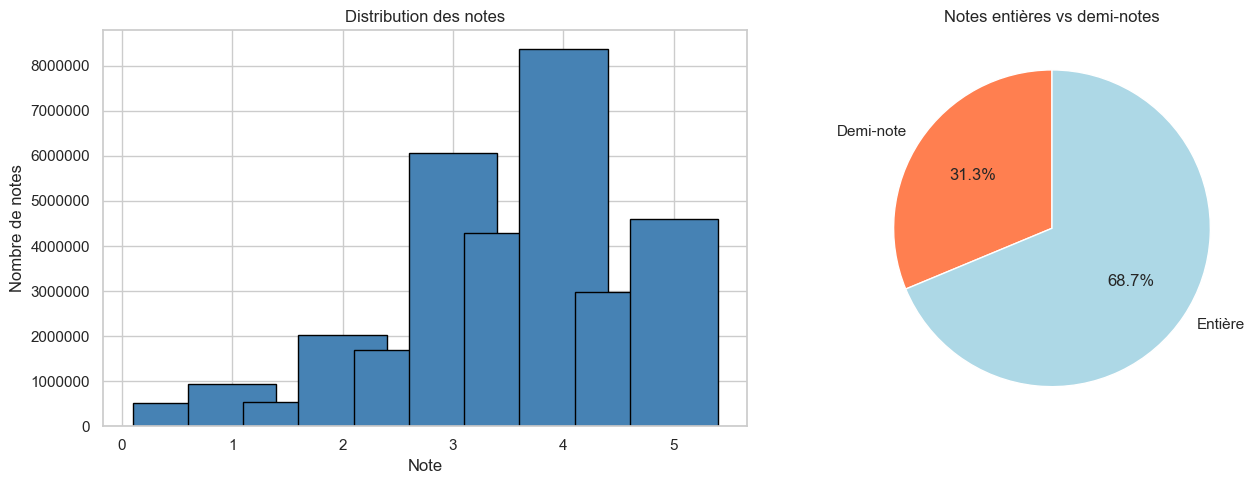


Notes entières : 21,994,518 (68.7%)
Demi-notes     : 10,005,686 (31.3%)

Notes >= 3.5 : 20,228,336 (63.2%)
→ Les utilisateurs ont tendance à noter positivement (biais de sélection :
  on regarde surtout les films qu'on pense apprécier).


In [13]:
# 2. Distribution détaillée des notes (notes entières vs demi-notes)
print("=== Analyse détaillée de la distribution des notes ===")

if 'rating' in df.columns:
    # Distribution complète
    ratingDist = df['rating'].value_counts().sort_index()
    
    # Séparer notes entières et demi-notes
    ratingDistDF = pd.DataFrame({
        'rating': ratingDist.index,
        'count': ratingDist.values
    })
    ratingDistDF['type'] = ratingDistDF['rating'].apply(
        lambda r: "Entière" if r % 1 == 0 else "Demi-note"
    )
    
    # Visualisation
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))
    
    # Barplot principal
    axes[0].bar(ratingDistDF['rating'], ratingDistDF['count'], 
                color='steelblue', edgecolor='black')
    axes[0].set_title("Distribution des notes")
    axes[0].set_xlabel("Note")
    axes[0].set_ylabel("Nombre de notes")
    axes[0].ticklabel_format(style='plain', axis='y')
    
    # Notes entières vs demi-notes
    typeDist = ratingDistDF.groupby('type')['count'].sum()
    axes[1].pie(typeDist.values, labels=typeDist.index, autopct='%1.1f%%', 
                startangle=90, colors=['coral', 'lightblue'])
    axes[1].set_title("Notes entières vs demi-notes")
    
    plt.tight_layout()
    plt.show()
    
    # Statistiques
    print(f"\nNotes entières : {typeDist.get('Entière', 0):,} ({typeDist.get('Entière', 0)/len(df)*100:.1f}%)")
    print(f"Demi-notes     : {typeDist.get('Demi-note', 0):,} ({typeDist.get('Demi-note', 0)/len(df)*100:.1f}%)")
    
    # Proportion de notes positives
    nPositives = len(df[df['rating'] >= 3.5])
    print(f"\nNotes >= 3.5 : {nPositives:,} ({nPositives/len(df)*100:.1f}%)")
    print("→ Les utilisateurs ont tendance à noter positivement (biais de sélection :")
    print("  on regarde surtout les films qu'on pense apprécier).")

In [14]:
# 3. Analyse du cold start (utilisateurs et films peu notés)
print("=== Analyse du Cold Start ===")

if 'userId' in df.columns:
    ratingsPerUser = df.groupby('userId').size()
    
    print("\n--- Utilisateurs (Cold Start) ---")
    for seuil in [5, 10, 20]:
        n = len(ratingsPerUser[ratingsPerUser < seuil])
        print(f"Utilisateurs avec < {seuil} notes : {n:,} ({n/len(ratingsPerUser)*100:.1f}%)")
    
    print("\n→ Ces utilisateurs sont difficiles à recommander (cold start).")
    print("→ Les algorithmes de recommandation les gèrent via la régularisation,")
    print("  mais leur précision sera plus faible.")

if 'movieId' in df.columns:
    ratingsPerMovie = df.groupby('movieId').size()
    
    print("\n--- Films (Cold Start) ---")
    for seuil in [5, 10, 50]:
        n = len(ratingsPerMovie[ratingsPerMovie < seuil])
        print(f"Films avec < {seuil} notes : {n:,} ({n/len(ratingsPerMovie)*100:.1f}%)")
    
    print("\n→ Les films peu notés sont également difficiles à recommander.")

=== Analyse du Cold Start ===

--- Utilisateurs (Cold Start) ---
Utilisateurs avec < 5 notes : 0 (0.0%)
Utilisateurs avec < 10 notes : 0 (0.0%)
Utilisateurs avec < 20 notes : 0 (0.0%)

→ Ces utilisateurs sont difficiles à recommander (cold start).
→ Les algorithmes de recommandation les gèrent via la régularisation,
  mais leur précision sera plus faible.

--- Films (Cold Start) ---
Films avec < 5 notes : 40,548 (48.0%)
Films avec < 10 notes : 52,471 (62.1%)
Films avec < 50 notes : 68,398 (81.0%)

→ Les films peu notés sont également difficiles à recommander.


=== Top films avec seuil minimal de votes ===
Seuil minimal retenu (P75) : 25 notes

Top 20 films les mieux notés (min 25 notes):


,title,genres,nbRatings,avgRating
46252,Planet Earth II (2016),Documentary,1956,4.4468
40985,Planet Earth (2006),Documentary,2948,4.4444
46103,Band of Brothers (2001),Action|Drama|War,2811,4.4265
314,"Shawshank Redemption, The (1994)",Crime|Drama,102929,4.4046
46487,Cosmos,(no genres listed),615,4.3301
840,"Godfather, The (1972)",Crime|Drama,66440,4.3170
61090,Parasite (2019),Comedy|Drama,11670,4.3123
35450,The Roosevelts: An Intimate History (2014),Documentary,44,4.3068
50126,Blue Planet II (2017),Documentary,1163,4.3001
59131,Twin Peaks (1989),Drama|Mystery,1140,4.2987


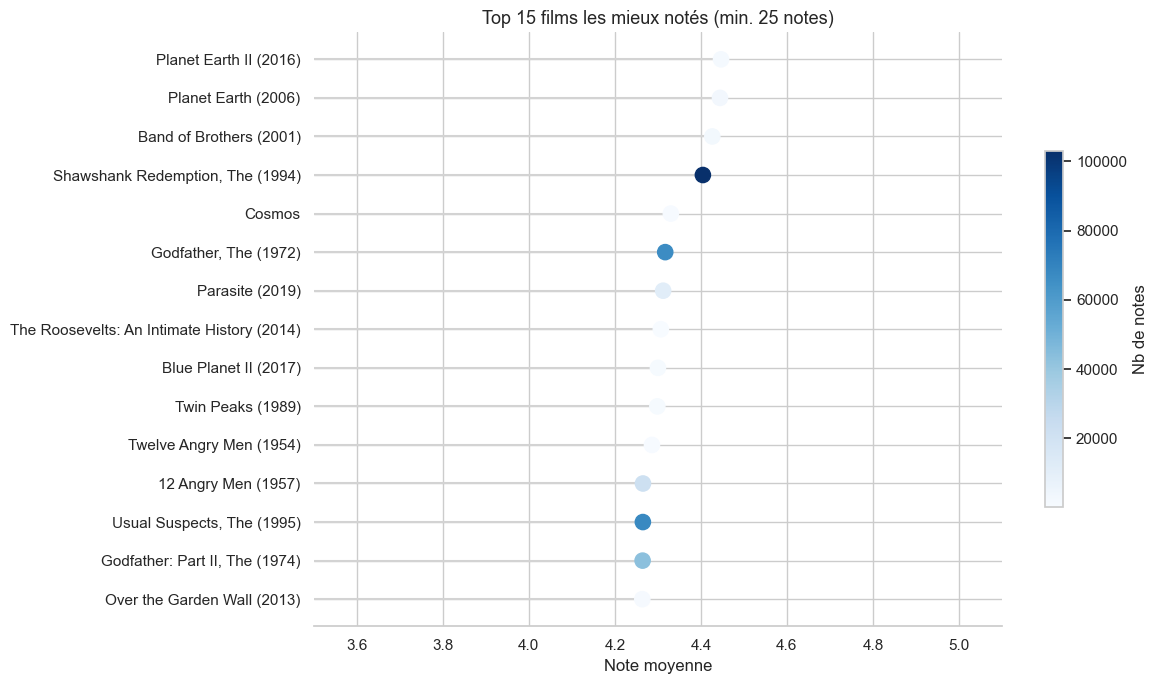

In [15]:
# 4. Top films avec seuil minimal de votes (méthode robuste)
print("=== Top films avec seuil minimal de votes ===")

if not df.empty and not dfMovies.empty:
    # Calculer le seuil (percentile 75 du nombre de notes par film)
    ratingsPerMovie = df.groupby('movieId').agg({
        'rating': ['count', 'mean']
    })
    ratingsPerMovie.columns = ['nbRatings', 'avgRating']
    
    seuil = int(ratingsPerMovie['nbRatings'].quantile(0.75))
    print(f"Seuil minimal retenu (P75) : {seuil} notes")
    
    # Top films avec seuil
    topMovies = ratingsPerMovie[ratingsPerMovie['nbRatings'] >= seuil].copy()
    topMovies = topMovies.merge(
        dfMovies[['movieId', 'title', 'genres']],
        left_index=True,
        right_on='movieId',
        how='left'
    )
    
    # Filtrer les films avec année et genres valides
    if 'year_movielens' in dfMovies.columns:
        topMovies = topMovies.merge(
            dfMovies[['movieId', 'year_movielens']],
            on='movieId',
            how='left'
        )
        topMovies = topMovies[
            topMovies['year_movielens'].notna() &
            topMovies['genres'].notna() &
            (topMovies['genres'] != '(no genres listed)')
        ]
    
    topMovies = topMovies.sort_values('avgRating', ascending=False).head(20)
    
    print(f"\nTop 20 films les mieux notés (min {seuil} notes):")
    display(topMovies[['title', 'genres', 'nbRatings', 'avgRating']].head(20))
    
    # Visualisation lollipop
    if len(topMovies) > 0:
        top15 = topMovies.head(15).iloc[::-1].reset_index(drop=True)
        
        fig, ax = plt.subplots(figsize=(12, 7))
        
        yPos = np.arange(len(top15))
        norm = plt.Normalize(top15['nbRatings'].min(), top15['nbRatings'].max())
        cmap = plt.cm.Blues
        colors = cmap(norm(top15['nbRatings']))
        
        # Tiges
        ax.hlines(y=yPos, xmin=3.5, xmax=top15['avgRating'].values,
                  color='lightgrey', linewidth=1.5, zorder=1)
        
        # Points
        ax.scatter(top15['avgRating'], yPos, color=colors, s=120, zorder=2)
        
        # Labels
        if 'year_movielens' in top15.columns:
            labels = [f"{row['title']} ({int(row['year_movielens'])})" 
                     for _, row in top15.iterrows()]
        else:
            labels = top15['title'].values
        
        ax.set_yticks(yPos)
        ax.set_yticklabels(labels)
        
        # Colorbar
        sm = plt.cm.ScalarMappable(cmap=cmap, norm=norm)
        sm.set_array([])
        plt.colorbar(sm, ax=ax, label="Nb de notes", shrink=0.6)
        
        ax.set_xlim(3.5, 5.1)
        ax.set_title(f"Top 15 films les mieux notés (min. {seuil} notes)", fontsize=13)
        ax.set_xlabel("Note moyenne")
        ax.spines[["top", "right", "left"]].set_visible(False)
        ax.tick_params(left=False)
        
        plt.tight_layout()
        plt.show()

=== Analyse approfondie des genres ===

Top 15 genres par volume de notes:


,nbRatings,avgRating,nbFilms
genres,,,
Drama,13973271,3.6825,33152
Comedy,11206926,3.4324,22448
Action,9665213,3.4764,9296
Thriller,8679464,3.5317,11555
Adventure,7590522,3.5234,5156
Sci-Fi,5717337,3.4917,4797
Romance,5524615,3.5450,10048
Crime,5373051,3.6918,6704
Fantasy,3702759,3.5122,3784


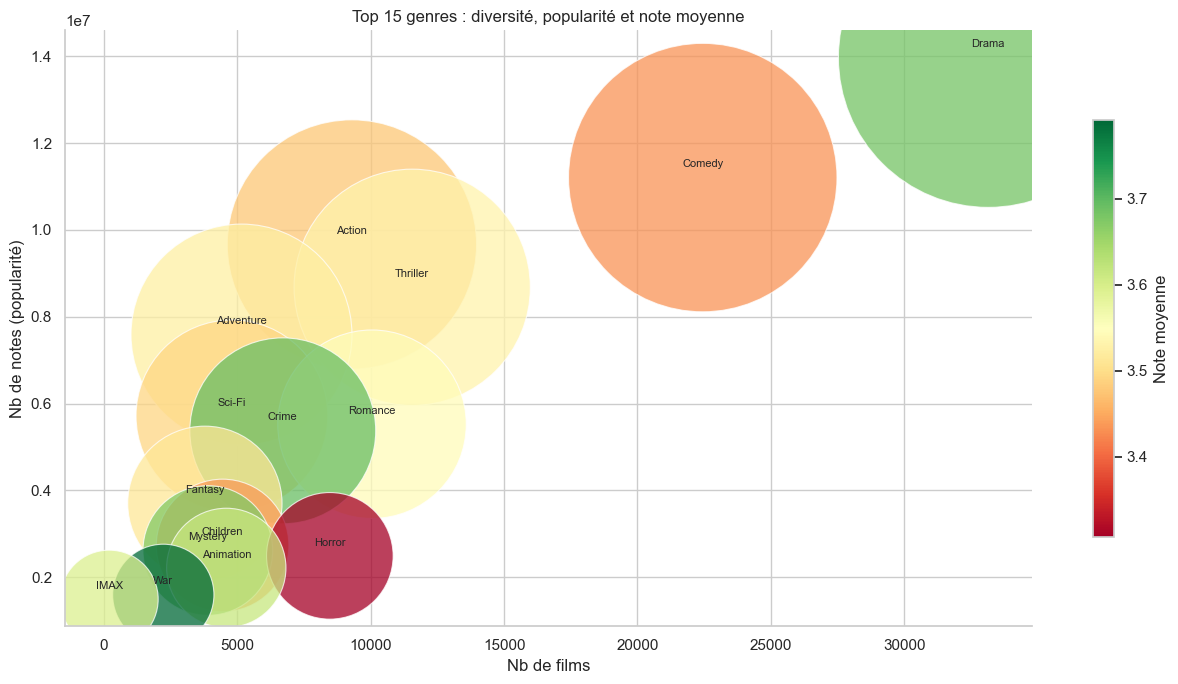

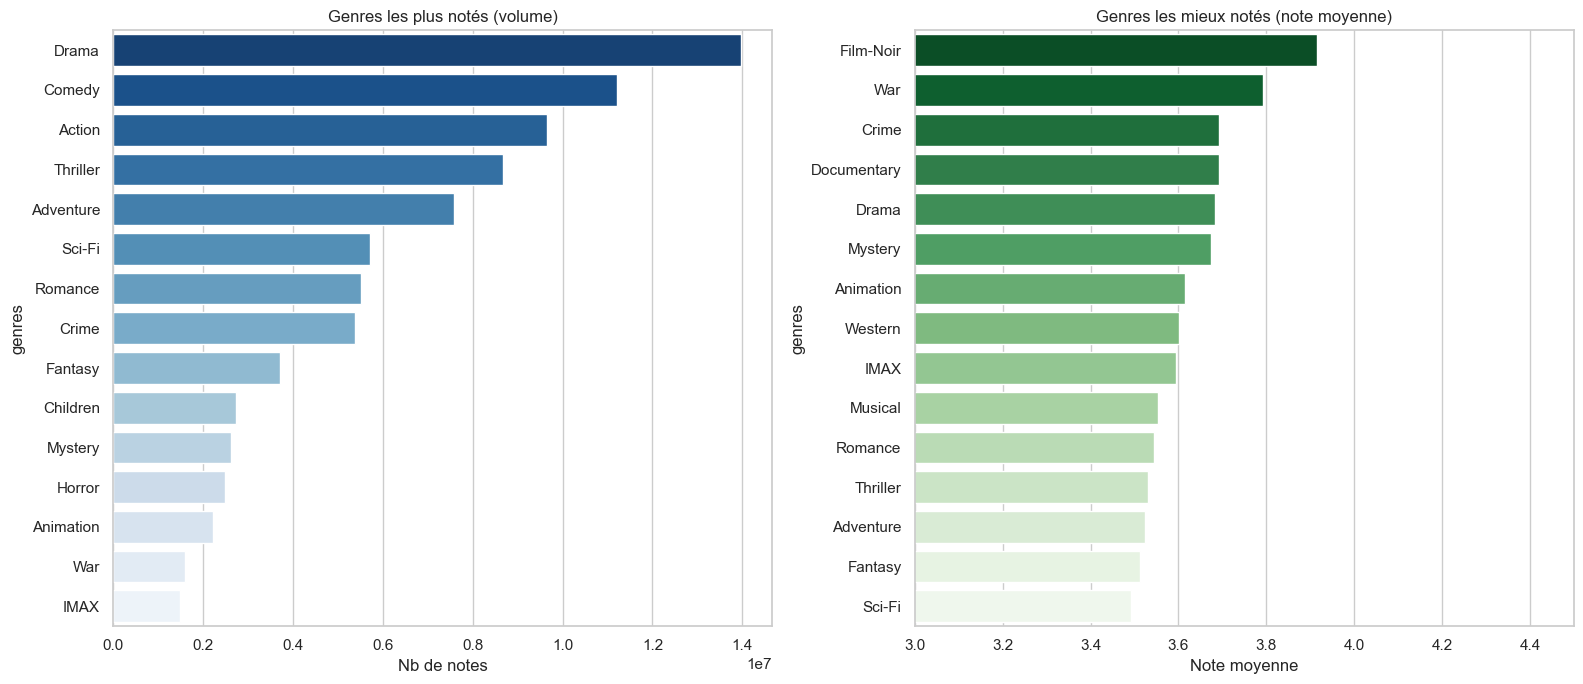

In [16]:
# 5. Analyse approfondie des genres (bubble chart)
print("=== Analyse approfondie des genres ===")

if not dfMovies.empty and 'genres' in dfMovies.columns and not df.empty:
    # Exploser les genres
    moviesExploded = dfMovies.copy()
    moviesExploded['genres'] = moviesExploded['genres'].str.split('|')
    moviesExploded = moviesExploded.explode('genres')
    
    # Joindre avec les ratings
    ratingsWithGenres = df.merge(
        moviesExploded[['movieId', 'genres']],
        on='movieId',
        how='left'
    )
    
    # Statistiques par genre
    genreStats = ratingsWithGenres.groupby('genres').agg({
        'rating': ['count', 'mean'],
        'movieId': 'nunique'
    }).round(4)
    genreStats.columns = ['nbRatings', 'avgRating', 'nbFilms']
    genreStats = genreStats.sort_values('nbRatings', ascending=False)
    
    print(f"\nTop 15 genres par volume de notes:")
    display(genreStats.head(15))
    
    # Visualisation bubble chart
    genreTop15 = genreStats.head(15)
    
    fig, ax = plt.subplots(figsize=(13, 7))
    
    norm = plt.Normalize(genreTop15['avgRating'].min(), genreTop15['avgRating'].max())
    cmap = plt.cm.RdYlGn
    colors = cmap(norm(genreTop15['avgRating']))
    
    ax.scatter(
        genreTop15['nbFilms'],
        genreTop15['nbRatings'],
        s=genreTop15['nbRatings'] / 300,
        c=colors,
        alpha=0.75,
        edgecolors='white',
        linewidths=0.8
    )
    
    for _, row in genreTop15.iterrows():
        ax.annotate(
            row.name,
            (row['nbFilms'], row['nbRatings']),
            fontsize=8, ha='center', va='bottom',
            xytext=(0, 6), textcoords='offset points'
        )
    
    sm = plt.cm.ScalarMappable(cmap=cmap, norm=norm)
    sm.set_array([])
    plt.colorbar(sm, ax=ax, label="Note moyenne", shrink=0.7)
    
    ax.set_xlabel("Nb de films")
    ax.set_ylabel("Nb de notes (popularité)")
    ax.set_title("Top 15 genres : diversité, popularité et note moyenne")
    ax.spines[["top", "right"]].set_visible(False)
    
    plt.tight_layout()
    plt.show()
    
    # Visualisation double barplot
    fig, axes = plt.subplots(1, 2, figsize=(16, 7))
    
    # Volume de notes par genre
    topGenre = genreStats.head(15)
    sns.barplot(data=topGenre.reset_index(), y='genres', x='nbRatings', 
                ax=axes[0], palette='Blues_r')
    axes[0].set_title("Genres les plus notés (volume)")
    axes[0].set_xlabel("Nb de notes")
    
    # Note moyenne par genre
    genreSorted = genreStats.sort_values('avgRating', ascending=False).head(15)
    sns.barplot(data=genreSorted.reset_index(), y='genres', x='avgRating', 
                ax=axes[1], palette='Greens_r')
    axes[1].set_title("Genres les mieux notés (note moyenne)")
    axes[1].set_xlabel("Note moyenne")
    axes[1].set_xlim(3.0, 4.5)
    
    plt.tight_layout()
    plt.show()

=== Évolution temporelle détaillée ===


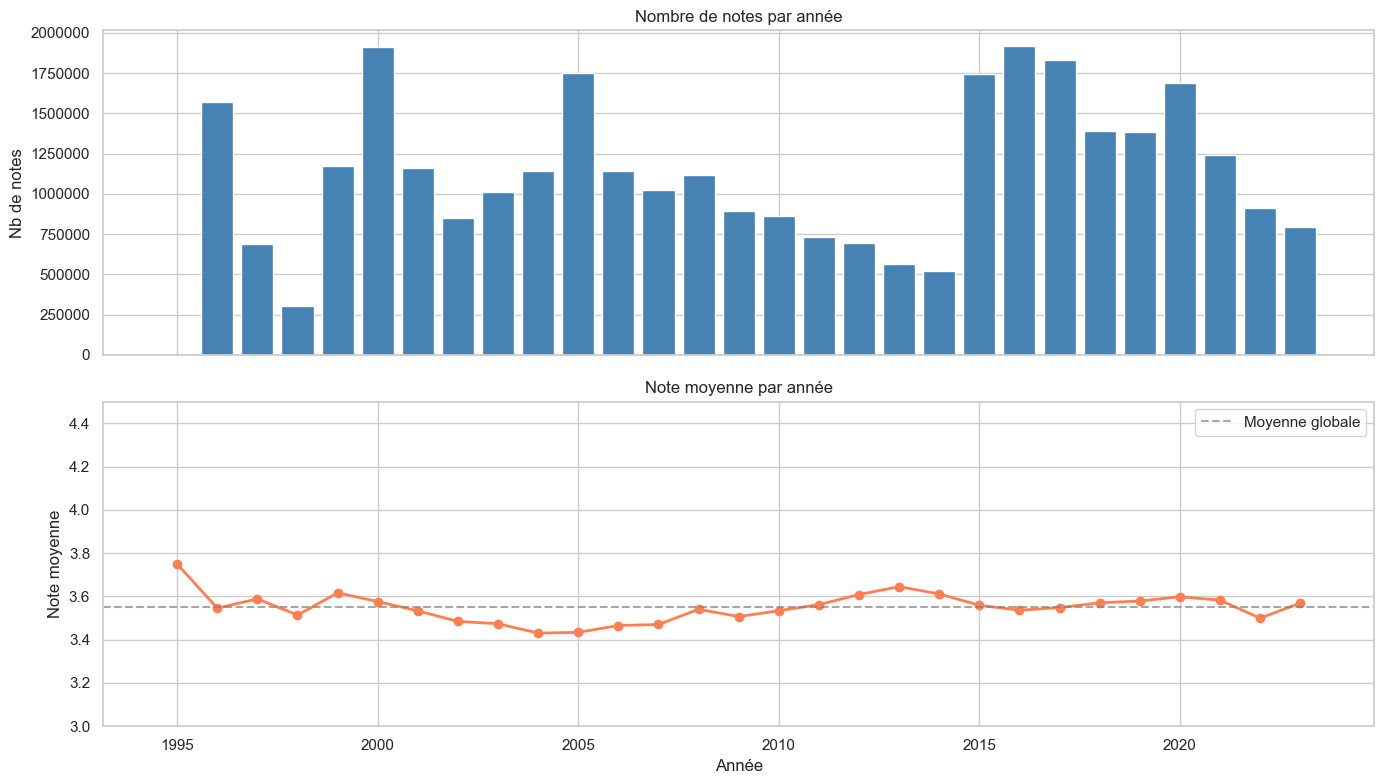


Période analysée : 1995 - 2023
Note moyenne globale : 3.550


In [17]:
# 6. Évolution temporelle détaillée
print("=== Évolution temporelle détaillée ===")

if 'year' in df.columns and 'month' in df.columns:
    # Par année
    yearly = df.groupby('year').agg({
        'rating': ['count', 'mean']
    })
    yearly.columns = ['nbRatings', 'avgRating']
    
    # Visualisation
    fig, axes = plt.subplots(2, 1, figsize=(14, 8), sharex=True)
    
    axes[0].bar(yearly.index, yearly['nbRatings'], color='steelblue')
    axes[0].set_title("Nombre de notes par année")
    axes[0].set_ylabel("Nb de notes")
    axes[0].ticklabel_format(style='plain', axis='y')
    
    axes[1].plot(yearly.index, yearly['avgRating'], marker='o', 
                color='coral', linewidth=2)
    axes[1].axhline(y=yearly['avgRating'].mean(), linestyle='--',
                   color='gray', alpha=0.7, label='Moyenne globale')
    axes[1].set_title("Note moyenne par année")
    axes[1].set_ylabel("Note moyenne")
    axes[1].set_xlabel("Année")
    axes[1].legend()
    axes[1].set_ylim(3.0, 4.5)
    
    plt.tight_layout()
    plt.show()
    
    print(f"\nPériode analysée : {yearly.index.min()} - {yearly.index.max()}")
    print(f"Note moyenne globale : {yearly['avgRating'].mean():.3f}")

=== Analyse du biais temporel ===


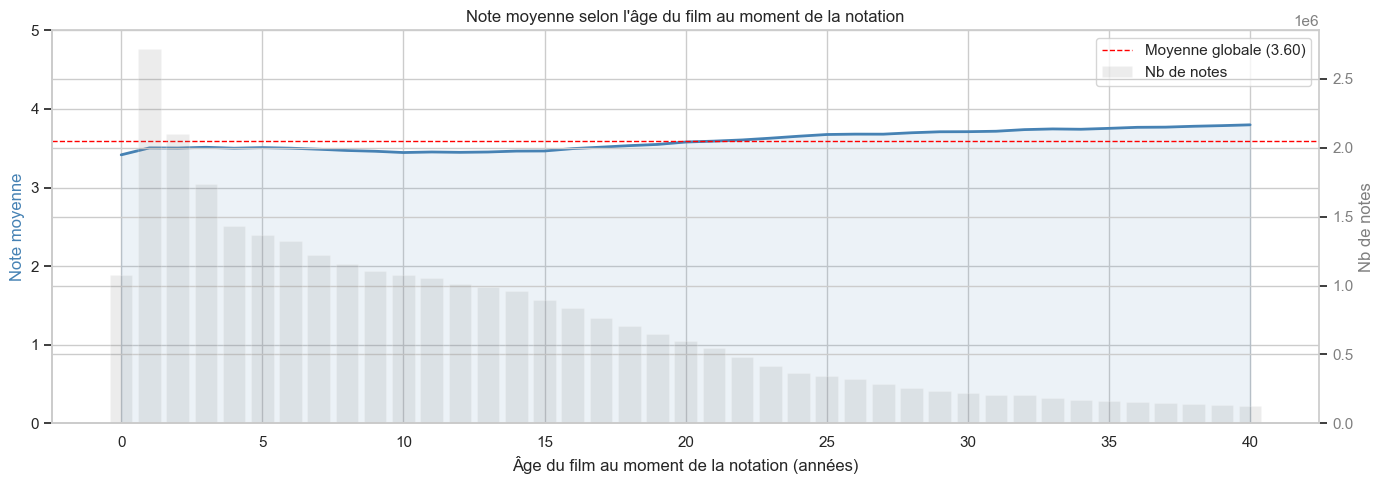


→ Cette analyse révèle si les films récents sont mieux notés
  que les films anciens, ou vice versa.


In [18]:
# 7. Biais temporel : note selon l'âge du film au moment de la notation
print("=== Analyse du biais temporel ===")

if 'year' in df.columns and not dfMovies.empty:
    # Extraire l'année de sortie depuis le titre si pas déjà fait
    if 'releaseYear' not in dfMovies.columns and 'title' in dfMovies.columns:
        dfMovies['releaseYear'] = dfMovies['title'].str.extract(r'\((\d{4})\)').astype('Int64')
    
    if 'releaseYear' in dfMovies.columns:
        # Joindre avec les ratings
        ratingsTemporal = df.merge(
            dfMovies[['movieId', 'releaseYear']],
            on='movieId',
            how='inner'
        )
        
        # Calculer l'âge du film au moment de la notation
        ratingsTemporal = ratingsTemporal[
            ratingsTemporal['releaseYear'].notna() &
            ratingsTemporal['year'].notna()
        ].copy()
        ratingsTemporal['ageAtRating'] = ratingsTemporal['year'] - ratingsTemporal['releaseYear']
        
        # Filtrer les âges raisonnables (0-40 ans)
        ratingsTemporal = ratingsTemporal[
            (ratingsTemporal['ageAtRating'] >= 0) & 
            (ratingsTemporal['ageAtRating'] <= 40)
        ]
        
        # Agréger par âge
        ageStats = ratingsTemporal.groupby('ageAtRating').agg({
            'rating': ['mean', 'count']
        })
        ageStats.columns = ['avgRating', 'nbRatings']
        
        # Visualisation
        fig, ax1 = plt.subplots(figsize=(14, 5))
        
        ax1.plot(ageStats.index, ageStats['avgRating'],
                color='steelblue', linewidth=2)
        ax1.fill_between(ageStats.index, ageStats['avgRating'],
                         alpha=0.1, color='steelblue')
        
        # Ligne de référence
        meanGlobal = ageStats['avgRating'].mean()
        ax1.axhline(meanGlobal, color='red', linestyle='--', linewidth=1,
                   label=f'Moyenne globale ({meanGlobal:.2f})')
        
        ax2 = ax1.twinx()
        ax2.bar(ageStats.index, ageStats['nbRatings'],
               alpha=0.15, color='grey', label='Nb de notes')
        ax2.set_ylabel("Nb de notes", color='grey')
        ax2.tick_params(axis='y', labelcolor='grey')
        
        ax1.set_xlabel("Âge du film au moment de la notation (années)")
        ax1.set_ylabel("Note moyenne", color='steelblue')
        ax1.set_ylim(0, 5)
        ax1.set_title("Note moyenne selon l'âge du film au moment de la notation")
        ax1.spines[["top", "right"]].set_visible(False)
        
        lines1, labels1 = ax1.get_legend_handles_labels()
        lines2, labels2 = ax2.get_legend_handles_labels()
        ax1.legend(lines1 + lines2, labels1 + labels2, loc='upper right')
        
        plt.tight_layout()
        plt.show()
        
        print("\n→ Cette analyse révèle si les films récents sont mieux notés")
        print("  que les films anciens, ou vice versa.")

=== Notes moyennes par année de sortie ===


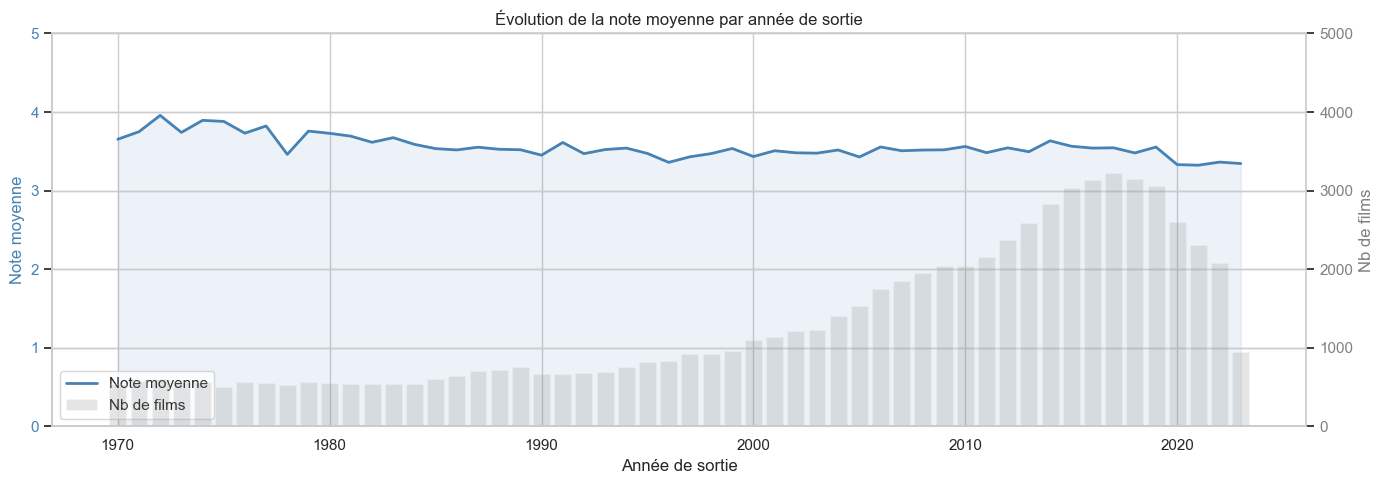


Période analysée : 1970 - 2023
Note moyenne globale : 3.559


In [19]:
# 8. Notes moyennes par année de sortie
print("=== Notes moyennes par année de sortie ===")

if not dfMovies.empty and not df.empty:
    if 'releaseYear' in dfMovies.columns:
        # Joindre ratings avec année de sortie
        ratingsByReleaseYear = df.merge(
            dfMovies[['movieId', 'releaseYear']],
            on='movieId',
            how='inner'
        )
        
        # Filtrer les années valides (>= 1970 pour éviter sous-représentation)
        ratingsByReleaseYear = ratingsByReleaseYear[
            (ratingsByReleaseYear['releaseYear'].notna()) &
            (ratingsByReleaseYear['releaseYear'] >= 1970)
        ]
        
        # Agréger
        yearStats = ratingsByReleaseYear.groupby('releaseYear').agg({
            'rating': ['mean', 'count'],
            'movieId': 'nunique'
        })
        yearStats.columns = ['avgRating', 'nbRatings', 'nbFilms']
        yearStats = yearStats.sort_index()
        
        # Visualisation
        fig, ax1 = plt.subplots(figsize=(14, 5))
        
        # Note moyenne (axe principal)
        ax1.plot(yearStats.index, yearStats['avgRating'],
                color='steelblue', linewidth=2, label='Note moyenne')
        ax1.fill_between(yearStats.index, yearStats['avgRating'],
                         alpha=0.1, color='steelblue')
        ax1.set_ylabel("Note moyenne", color='steelblue')
        ax1.set_ylim(0, 5)
        ax1.tick_params(axis='y', labelcolor='steelblue')
        
        # Nb de films (axe secondaire)
        ax2 = ax1.twinx()
        ax2.bar(yearStats.index, yearStats['nbFilms'],
               alpha=0.2, color='grey', label='Nb de films')
        ax2.set_ylabel("Nb de films", color='grey')
        ax2.set_ylim(0, 5000)
        ax2.tick_params(axis='y', labelcolor='grey')
        
        ax1.set_xlabel("Année de sortie")
        ax1.set_title("Évolution de la note moyenne par année de sortie")
        ax1.spines[["top", "right"]].set_visible(False)
        
        # Légende combinée
        lines1, labels1 = ax1.get_legend_handles_labels()
        lines2, labels2 = ax2.get_legend_handles_labels()
        ax1.legend(lines1 + lines2, labels1 + labels2, loc='lower left')
        
        plt.tight_layout()
        plt.show()
        
        print(f"\nPériode analysée : {yearStats.index.min()} - {yearStats.index.max()}")
        print(f"Note moyenne globale : {yearStats['avgRating'].mean():.3f}")

In [20]:
# 9. Synthèse et conclusions
print("=== Synthèse et Conclusions ===\n")

if not df.empty:
    nbRatings = len(df)
    nbUsers = df['userId'].nunique()
    nbMovies = df['movieId'].nunique()
    avgRating = df['rating'].mean()
    
    # Calculer la sparsité
    totalCells = nbUsers * nbMovies
    sparsity = 1 - (nbRatings / totalCells)
    
    # Cold start
    ratingsPerUser = df.groupby('userId').size()
    ratingsPerMovie = df.groupby('movieId').size()
    coldStartUsers = len(ratingsPerUser[ratingsPerUser < 20])
    coldStartMovies = len(ratingsPerMovie[ratingsPerMovie < 5])
    
    # Genres populaires
    if not dfMovies.empty and 'genres' in dfMovies.columns:
        moviesExploded = dfMovies.copy()
        moviesExploded['genres'] = moviesExploded['genres'].str.split('|')
        moviesExploded = moviesExploded.explode('genres')
        ratingsWithGenres = df.merge(moviesExploded[['movieId', 'genres']], on='movieId', how='left')
        genreStats = ratingsWithGenres.groupby('genres')['rating'].count().sort_values(ascending=False)
        topGenre = genreStats.head(1).index[0] if len(genreStats) > 0 else "N/A"
    
    print("| Dimension            | Observation clé                                      |")
    print("|----------------------|------------------------------------------------------|")
    print(f"| **Sparsité**         | {sparsity:.2%} → Matrice très creuse, ALS bien adapté            |")
    print(f"| **Distribution**     | Biais positif : {len(df[df['rating'] >= 3.5])/len(df)*100:.1f}% des notes ≥ 3.5          |")
    print(f"| **Cold start users** | {coldStartUsers:,} users ({coldStartUsers/nbUsers*100:.1f}%) ont noté < 20 films                     |")
    print(f"| **Cold start films** | {coldStartMovies:,} films ({coldStartMovies/nbMovies*100:.1f}%) ont < 5 notes                           |")
    if not dfMovies.empty and 'genres' in dfMovies.columns:
        print(f"| **Genre populaire**  | {topGenre} domine en volume           |")
    print(f"| **Note moyenne**    | {avgRating:.2f}/5.0 (stable)  |")
    
    print("\n**→ Pour la modélisation ALS**, on retiendra un seuil minimal de notes")
    print("   par utilisateur et par film pour limiter le cold start.")
    print("**→ Pour la recommandation contenu**, les genres MovieLens enrichiront")
    print("   les features au-delà des seuls ratings.")

=== Synthèse et Conclusions ===

| Dimension            | Observation clé                                      |
|----------------------|------------------------------------------------------|
| **Sparsité**         | 99.81% → Matrice très creuse, ALS bien adapté            |
| **Distribution**     | Biais positif : 63.2% des notes ≥ 3.5          |
| **Cold start users** | 0 users (0.0%) ont noté < 20 films                     |
| **Cold start films** | 40,548 films (48.0%) ont < 5 notes                           |
| **Genre populaire**  | Drama domine en volume           |
| **Note moyenne**    | 3.54/5.0 (stable)  |

**→ Pour la modélisation ALS**, on retiendra un seuil minimal de notes
   par utilisateur et par film pour limiter le cold start.
**→ Pour la recommandation contenu**, les genres MovieLens enrichiront
   les features au-delà des seuls ratings.


# ── 🚀 MODÉLISATION AVEC SPARK MLlib ─────────────────────────────────────────

## Section : Modélisation de Recommandation avec ALS

Cette section implémente un système de recommandation utilisant l'algorithme **ALS (Alternating Least Squares)** de Spark MLlib.

### ⚠️ Prérequis : Java

**PySpark nécessite Java pour fonctionner.** Si vous obtenez une erreur `JAVA_GATEWAY_EXITED`, installez Java :

#### Option 1 : Installation manuelle
1. Téléchargez **Java 11** (LTS) depuis [Adoptium](https://adoptium.net/)
2. Installez Java et ajoutez-le au PATH système
3. Redémarrez votre terminal/notebook

#### Option 2 : Avec Chocolatey (Windows)
```powershell
choco install openjdk11
```

#### Option 3 : Avec winget (Windows)
```powershell
winget install Microsoft.OpenJDK.11
```

#### Vérification
Après installation, vérifiez avec :
```powershell
java -version
```

**Plan** :
1. Initialisation de Spark
2. Chargement des données avec Spark
3. Exploration et nettoyage
4. Préparation des données pour ALS
5. Entraînement du modèle
6. Évaluation (RMSE, MAE)
7. Optimisation des hyperparamètres

In [21]:
# ⚠️ CRITIQUE : Configuration JVM - DOIT être exécutée AVANT tout import PySpark
# Cette cellule doit être exécutée en PREMIER, avant toute autre cellule qui importe PySpark
# Les variables d'environnement doivent être définies avant que la JVM soit lancée

import os

# Créer le répertoire de spill si nécessaire
os.makedirs("C:/tmp/spark", exist_ok=True)
os.environ["SPARK_LOCAL_DIRS"] = "C:/tmp/spark"

# Configuration JVM optimisée pour 32 Go de RAM
# -Xss16m : Stack size par thread (16m au lieu de ~512k par défaut) pour éviter StackOverflowError
os.environ["_JAVA_OPTIONS"] = "-Xmx20g -Xms4g -XX:+UseG1GC -XX:G1HeapRegionSize=32m -Xss16m"

# Configuration Spark via PYSPARK_SUBMIT_ARGS
os.environ["PYSPARK_SUBMIT_ARGS"] = "--driver-memory 20g pyspark-shell"

print("✅ JVM configurée — exécutez maintenant la cellule suivante")
print(f"   Mémoire max: 20g, démarrage: 4g")
print(f"   Garbage collector: G1GC")
print(f"   SPARK_LOCAL_DIRS: {os.environ.get('SPARK_LOCAL_DIRS')}")


✅ JVM configurée — exécutez maintenant la cellule suivante
   Mémoire max: 20g, démarrage: 4g
   Garbage collector: G1GC
   SPARK_LOCAL_DIRS: C:/tmp/spark


In [22]:
# ── 1. Initialisation de Spark ───────────────────────────────────────────────
# ⚠️ Si cette cellule prend plus de 2-3 minutes, INTERROMPEZ-LA (Kernel > Interrupt)
# et redémarrez le kernel (Kernel > Restart) avant de réessayer.

from pyspark.sql import SparkSession
from pyspark.sql import functions as F
from pyspark.sql.types import IntegerType, DoubleType, LongType
from pyspark.ml.recommendation import ALS
from pyspark.ml.evaluation import RegressionEvaluator
import os
import subprocess
import sys

# PySpark 3.5.1 - Configuration stable
print("Configuration Spark 3.5.1...")

# Recharger les variables d'environnement et détecter Java de manière robuste
print("Vérification de Java...")

java_found = False
java_path = None
java_home = None

# 1. Vérifier JAVA_HOME d'abord
if "JAVA_HOME" in os.environ:
    java_home = os.environ["JAVA_HOME"]
    java_path = os.path.join(java_home, "bin", "java.exe")
    if os.path.exists(java_path):
        java_found = True
        print(f"   ✅ Java trouvé via JAVA_HOME: {java_home}")

# 2. Si pas trouvé, chercher dans les emplacements courants sur Windows
if not java_found and sys.platform == "win32":
    common_paths = [
        r"C:\Program Files\Microsoft\jdk-11.0.30.7-hotspot",
        r"C:\Program Files\Java\jdk-11",
        r"C:\Program Files\Java\jdk-17",
        r"C:\Program Files\Java\jdk-8",
        r"C:\Program Files (x86)\Java\jdk-11",
        r"C:\Program Files (x86)\Java\jdk-17",
        r"C:\Program Files (x86)\Java\jdk-8",
    ]
    
    for java_dir in common_paths:
        test_java = os.path.join(java_dir, "bin", "java.exe")
        if os.path.exists(test_java):
            java_home = java_dir
            java_path = test_java
            java_found = True
            print(f"   ✅ Java trouvé: {java_dir}")
            break

# 3. Si toujours pas trouvé, essayer via le PATH système
if not java_found and sys.platform == "win32":
    try:
        import winreg
        # Récupérer le PATH système
        with winreg.OpenKey(winreg.HKEY_LOCAL_MACHINE, 
                           r"SYSTEM\CurrentControlSet\Control\Session Manager\Environment") as key:
            system_path = winreg.QueryValueEx(key, "PATH")[0]
            # Ajouter au PATH de la session actuelle
            current_path = os.environ.get("PATH", "")
            os.environ["PATH"] = system_path + os.pathsep + current_path
            
            # Essayer de trouver JAVA_HOME dans le registre
            try:
                java_home_reg = winreg.QueryValueEx(key, "JAVA_HOME")[0]
                if os.path.exists(java_home_reg):
                    java_home = java_home_reg
                    java_path = os.path.join(java_home, "bin", "java.exe")
                    if os.path.exists(java_path):
                        java_found = True
                        print(f"   ✅ Java trouvé via registre: {java_home}")
            except:
                pass
    except:
        pass

# 4. Tester avec java -version
if not java_found:
    try:
        result = subprocess.run(
            ["java", "-version"],
            stdout=subprocess.PIPE,
            stderr=subprocess.PIPE,
            text=True,
            timeout=5
        )
        version_output = result.stderr if result.stderr else result.stdout
        if "version" in version_output.lower():
            java_found = True
            print("   ✅ Java trouvé via PATH")
    except:
        pass

# 5. Si Java est trouvé, configurer JAVA_HOME et PATH
if java_found:
    if java_home and java_home not in os.environ.get("JAVA_HOME", ""):
        os.environ["JAVA_HOME"] = java_home
        print(f"   ✅ JAVA_HOME configuré: {java_home}")
    
    if java_path:
        java_bin_dir = os.path.dirname(java_path)
        current_path = os.environ.get("PATH", "")
        if java_bin_dir not in current_path:
            os.environ["PATH"] = java_bin_dir + os.pathsep + current_path
            print(f"   ✅ PATH mis à jour avec: {java_bin_dir}")
    
    # Afficher la version Java
    try:
        if java_path:
            result = subprocess.run(
                [java_path, "-version"],
                stdout=subprocess.PIPE,
                stderr=subprocess.PIPE,
                text=True,
                timeout=5
            )
        else:
            result = subprocess.run(
                ["java", "-version"],
                stdout=subprocess.PIPE,
                stderr=subprocess.PIPE,
                text=True,
                timeout=5
            )
        version_output = result.stderr if result.stderr else result.stdout
        first_line = version_output.split('\n')[0] if version_output else "Version inconnue"
        print(f"   {first_line}")
    except:
        print("   ⚠️ Impossible d'afficher la version Java")
else:
    print("❌ ERREUR: Java n'est pas installé ou n'est pas dans le PATH")
    print("\n📋 Solutions:")
    print("   1. Redémarrez le kernel du notebook (Kernel > Restart)")
    print("   2. Ou installez Java avec: winget install Microsoft.OpenJDK.11")
    print("   3. Ou téléchargez depuis: https://adoptium.net/")
    raise RuntimeError("Java est requis pour PySpark. Veuillez installer Java 8 ou 11 et redémarrer le kernel.")

# Configuration Spark 3.5.1 - Stable et optimisée
print("\n⏳ Démarrage Spark 3.5.1...")
print("   ⚠️ Cela peut prendre 10-30 secondes, patientez...")

# Nettoyer toute session existante
try:
    existing_spark = SparkSession.getActiveSession()
    if existing_spark is not None:
        print("   Arrêt session existante...")
        existing_spark.stop()
        import time
        time.sleep(2)
except:
    pass

try:
    # ✅ Configuration Spark optimisée pour 32 Go de RAM
    # ❌ NE PAS mettre spark.driver.memory ici, conflit avec PYSPARK_SUBMIT_ARGS
    spark = (
        SparkSession.builder
        .master("local[4]")
        .appName("ALS-SparkleMovie")
        .config("spark.sql.shuffle.partitions", "200")
        .config("spark.default.parallelism", "8")
        .config("spark.memory.fraction", "0.8")
        .config("spark.memory.storageFraction", "0.3")
        .config("spark.rdd.compress", "true")
        .config("spark.serializer", "org.apache.spark.serializer.KryoSerializer")
        .config("spark.ui.enabled", "false")
        .getOrCreate()
    )
    
    # Niveau de log WARN pour moins de bruit
    spark.sparkContext.setLogLevel("WARN")
    
    print(f"✅ Spark {spark.version} — mémoire: 20g")
    print(f"   Nombre de cœurs utilisés: {spark.sparkContext.defaultParallelism}")
    print(f"   Partitions shuffle: 200")
    print(f"   Serializer: Kryo")
    
except Exception as e:
    print(f"\n❌ Erreur lors du démarrage de Spark: {e}")
    print("\n💡 Solutions possibles:")
    print("   1. Redémarrez le kernel du notebook")
    print("   2. Vérifiez que Java est bien installé: java -version")
    print("   3. Fermez d'autres applications pour libérer de la mémoire")
    print("   4. Vérifiez les variables d'environnement JAVA_HOME")
    raise

Configuration Spark 3.5.1...
Vérification de Java...
   ✅ Java trouvé via JAVA_HOME: C:\Program Files\Microsoft\jdk-11.0.30.7-hotspot\
   Picked up _JAVA_OPTIONS: -Xmx20g -Xms4g -XX:+UseG1GC -XX:G1HeapRegionSize=32m -Xss16m

⏳ Démarrage Spark 3.5.1...
   ⚠️ Cela peut prendre 10-30 secondes, patientez...
✅ Spark 3.5.1 — mémoire: 20g
   Nombre de cœurs utilisés: 8
   Partitions shuffle: 200
   Serializer: Kryo


In [23]:
# ── 2. Chargement des données avec Spark ────────────────────────────────────

# Chemins des fichiers CSV
ratingsPath = os.path.join(dataDir, "ratings.csv")
moviesPath = os.path.join(dataDir, "movies.csv")

print("Chargement des données avec Spark...")

# Charger ratings.csv
ratingsSpark = spark.read \
    .option("header", "true") \
    .option("inferSchema", "true") \
    .csv(ratingsPath)

# Charger movies.csv
moviesSpark = spark.read \
    .option("header", "true") \
    .option("inferSchema", "true") \
    .csv(moviesPath)

# Mise en cache pour optimiser les accès répétés
ratingsSpark.cache()
moviesSpark.cache()

print(f"✅ Ratings chargés: {ratingsSpark.count():,} lignes")
print(f"✅ Movies chargés: {moviesSpark.count():,} lignes")

Chargement des données avec Spark...
✅ Ratings chargés: 32,000,204 lignes
✅ Movies chargés: 87,585 lignes


In [24]:
# ── 3. Exploration des données ───────────────────────────────────────────────

print("=== Structure des DataFrames ===\n")

print("── RATINGS ──")
ratingsSpark.printSchema()
print("\n10 premières lignes:")
ratingsSpark.show(10, truncate=False)

print("\n── MOVIES ──")
moviesSpark.printSchema()
print("\n10 premières lignes:")
moviesSpark.show(10, truncate=50)

# Dimensions
nbRatings = ratingsSpark.count()
nbUsers = ratingsSpark.select("userId").distinct().count()
nbMovies = ratingsSpark.select("movieId").distinct().count()
nbMoviesCatalog = moviesSpark.count()

print(f"\n=== Statistiques générales ===")
print(f"📊 Nombre de ratings    : {nbRatings:,}")
print(f"👤 Nombre d'utilisateurs : {nbUsers:,}")
print(f"🎬 Films notés          : {nbMovies:,}")
print(f"🎬 Films dans le catalogue: {nbMoviesCatalog:,}")

=== Structure des DataFrames ===

── RATINGS ──
root
 |-- userId: integer (nullable = true)
 |-- movieId: integer (nullable = true)
 |-- rating: double (nullable = true)
 |-- timestamp: integer (nullable = true)


10 premières lignes:
+------+-------+------+---------+
|userId|movieId|rating|timestamp|
+------+-------+------+---------+
|1     |17     |4.0   |944249077|
|1     |25     |1.0   |944250228|
|1     |29     |2.0   |943230976|
|1     |30     |5.0   |944249077|
|1     |32     |5.0   |943228858|
|1     |34     |2.0   |943228491|
|1     |36     |1.0   |944249008|
|1     |80     |5.0   |944248943|
|1     |110    |3.0   |943231119|
|1     |111    |5.0   |944249008|
+------+-------+------+---------+
only showing top 10 rows


── MOVIES ──
root
 |-- movieId: integer (nullable = true)
 |-- title: string (nullable = true)
 |-- genres: string (nullable = true)


10 premières lignes:
+-------+----------------------------------+-------------------------------------------+
|movieId|        

In [25]:
# ── 4. Nettoyage des données ─────────────────────────────────────────────────

print("=== Nettoyage des données ===\n")

# Vérifier les valeurs manquantes
print("── Valeurs manquantes dans ratings ──")
for col in ratingsSpark.columns:
    nNull = ratingsSpark.filter(F.col(col).isNull()).count()
    if nNull > 0:
        print(f"  {col}: {nNull:,} ({nNull/nbRatings*100:.2f}%)")

print("\n── Valeurs manquantes dans movies (colonnes clés) ──")
keyCols = ["movieId", "title", "genres"]
for col in keyCols:
    if col in moviesSpark.columns:
        nNull = moviesSpark.filter(F.col(col).isNull()).count()
        if nNull > 0:
            print(f"  {col}: {nNull:,} ({nNull/nbMoviesCatalog*100:.2f}%)")

# Supprimer les valeurs manquantes critiques
ratingsClean = ratingsSpark.filter(
    F.col("userId").isNotNull() &
    F.col("movieId").isNotNull() &
    F.col("rating").isNotNull()
)

# Vérifier les doublons (même utilisateur + même film)
duplicates = ratingsClean.groupBy("userId", "movieId").count().filter(F.col("count") > 1)
nbDuplicates = duplicates.count()

if nbDuplicates > 0:
    print(f"\n⚠️ {nbDuplicates:,} paires (userId, movieId) en doublon")
    print("   On garde la dernière note (plus récente)")
    # Garder la dernière note par timestamp
    from pyspark.sql.window import Window
    windowSpec = Window.partitionBy("userId", "movieId").orderBy(F.col("timestamp").desc())
    ratingsClean = ratingsClean.withColumn("rank", F.row_number().over(windowSpec)) \
                               .filter(F.col("rank") == 1) \
                               .drop("rank")
else:
    print("\n✅ Aucun doublon détecté")

# Vérifier la plage des ratings (doit être entre 0.5 et 5.0)
invalidRatings = ratingsClean.filter(
    (F.col("rating") < 0.5) | (F.col("rating") > 5.0)
).count()

if invalidRatings > 0:
    print(f"⚠️ {invalidRatings:,} ratings hors plage [0.5, 5.0] - suppression")
    ratingsClean = ratingsClean.filter(
        (F.col("rating") >= 0.5) & (F.col("rating") <= 5.0)
    )
else:
    print("✅ Tous les ratings sont dans la plage valide [0.5, 5.0]")

# Mettre à jour le cache
ratingsClean.unpersist()
ratingsClean.cache()

nbRatingsClean = ratingsClean.count()
print(f"\n✅ Données nettoyées: {nbRatingsClean:,} ratings ({nbRatingsClean/nbRatings*100:.1f}% conservés)")

=== Nettoyage des données ===

── Valeurs manquantes dans ratings ──

── Valeurs manquantes dans movies (colonnes clés) ──

✅ Aucun doublon détecté
✅ Tous les ratings sont dans la plage valide [0.5, 5.0]

✅ Données nettoyées: 32,000,204 ratings (100.0% conservés)


In [26]:
# ── 5. Analyse des tendances générales ─────────────────────────────────────

print("=== Analyse des tendances ===\n")

# 5.1. Films les mieux notés (avec seuil minimal de notes)
print("── Top 10 films les mieux notés ──")

# Calculer le seuil (percentile 75 du nombre de notes par film)
ratingsPerMovie = ratingsClean.groupBy("movieId") \
    .agg(
        F.count("rating").alias("nbRatings"),
        F.mean("rating").alias("avgRating")
    )

seuilMinNotes = int(
    ratingsPerMovie.select(F.percentile_approx("nbRatings", 0.75)).collect()[0][0]
)
print(f"Seuil minimal retenu (P75): {seuilMinNotes} notes\n")

# Top films avec seuil
topMovies = ratingsPerMovie \
    .filter(F.col("nbRatings") >= seuilMinNotes) \
    .join(moviesSpark.select("movieId", "title", "genres"), on="movieId", how="left") \
    .filter(
        F.col("genres").isNotNull() &
        (F.col("genres") != "(no genres listed)")
    ) \
    .select("title", "genres", "nbRatings", "avgRating") \
    .orderBy(F.col("avgRating").desc()) \
    .limit(10)

topMovies.show(10, truncate=50)

# 5.2. Genres les plus populaires
print("\n── Top 10 genres par volume de notes ──")

# Exploser les genres
from pyspark.sql.functions import explode, split

moviesWithGenres = moviesSpark \
    .withColumn("genre", explode(split(F.col("genres"), "\\|"))) \
    .filter(F.col("genre") != "(no genres listed)")

# Joindre avec ratings et agréger
genreStats = ratingsClean \
    .join(moviesWithGenres.select("movieId", "genre"), on="movieId", how="inner") \
    .groupBy("genre") \
    .agg(
        F.count("rating").alias("nbRatings"),
        F.mean("rating").alias("avgRating"),
        F.countDistinct("movieId").alias("nbFilms")
    ) \
    .orderBy(F.col("nbRatings").desc()) \
    .limit(10)

genreStats.show(10, truncate=False)

print("\n── Top 10 genres par note moyenne (min 1000 notes) ──")
genreStatsByRating = ratingsClean \
    .join(moviesWithGenres.select("movieId", "genre"), on="movieId", how="inner") \
    .groupBy("genre") \
    .agg(
        F.count("rating").alias("nbRatings"),
        F.mean("rating").alias("avgRating")
    ) \
    .filter(F.col("nbRatings") >= 1000) \
    .orderBy(F.col("avgRating").desc()) \
    .limit(10)

genreStatsByRating.show(10, truncate=False)

=== Analyse des tendances ===

── Top 10 films les mieux notés ──
Seuil minimal retenu (P75): 25 notes

+------------------------------------------+----------------+---------+------------------+
|                                     title|          genres|nbRatings|         avgRating|
+------------------------------------------+----------------+---------+------------------+
|                    Planet Earth II (2016)|     Documentary|     1956|4.4468302658486705|
|                       Planet Earth (2006)|     Documentary|     2948| 4.444369063772049|
|                   Band of Brothers (2001)|Action|Drama|War|     2811| 4.426538598363572|
|          Shawshank Redemption, The (1994)|     Crime|Drama|   102929| 4.404613860039444|
|                     Godfather, The (1972)|     Crime|Drama|    66440| 4.317030403371463|
|                           Parasite (2019)|    Comedy|Drama|    11670| 4.312253641816624|
|The Roosevelts: An Intimate History (2014)|     Documentary|       44| 4.306

=== Génération des visualisations ===



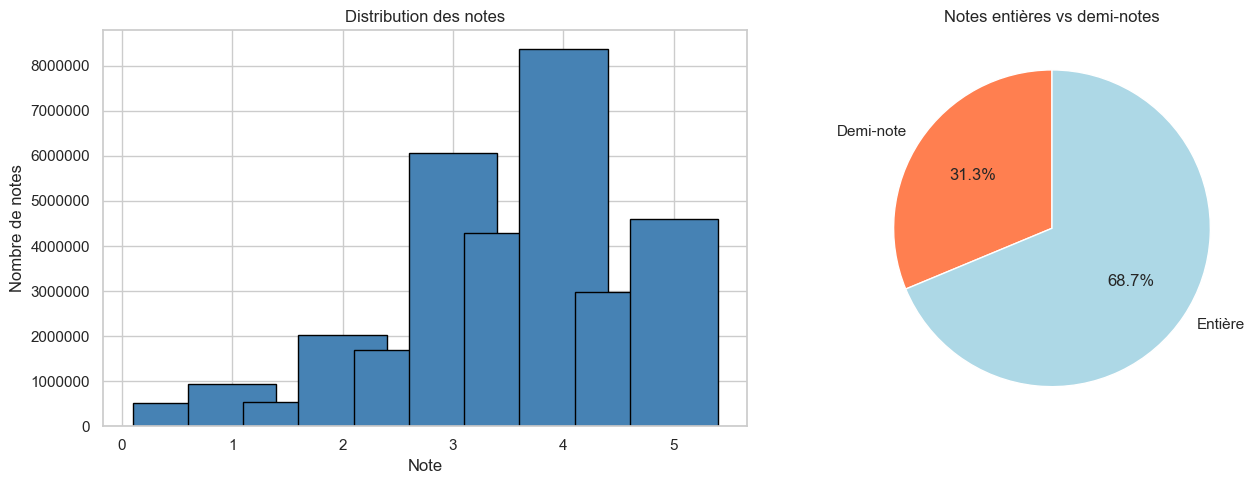

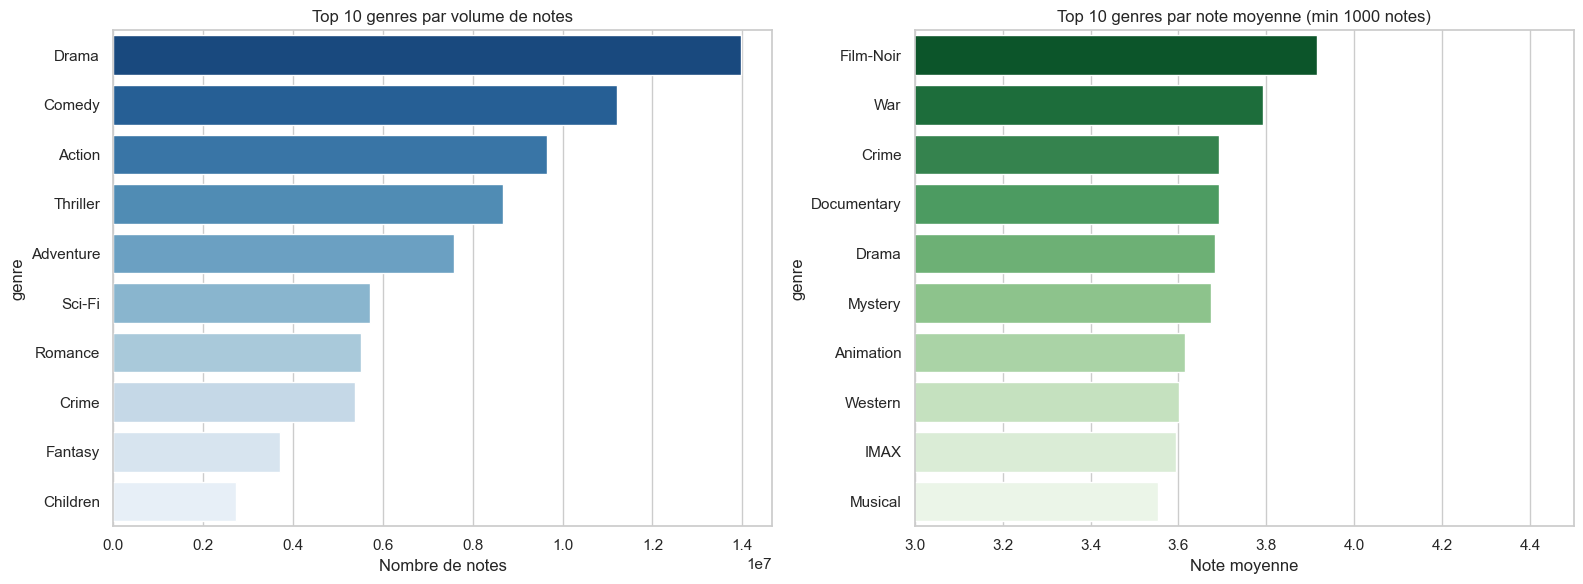

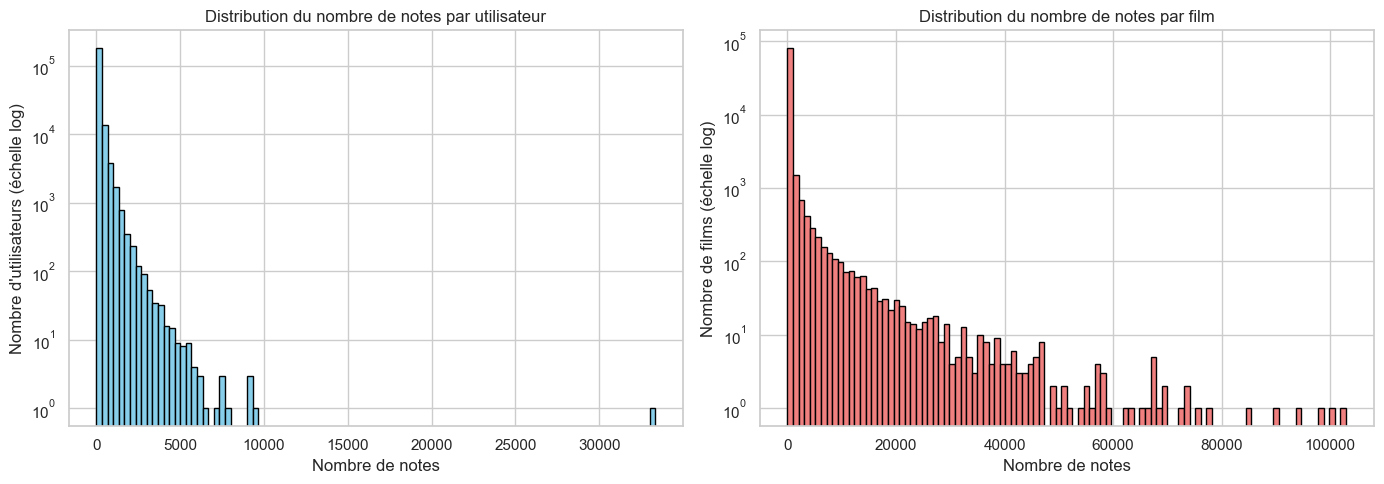

✅ Visualisations générées


In [27]:
# ── 6. Visualisations avec pandas/matplotlib ────────────────────────────────

# Convertir en pandas pour les visualisations
import matplotlib.pyplot as plt
import seaborn as sns

print("=== Génération des visualisations ===\n")

# 6.1. Distribution des notes
ratingDist = ratingsClean.groupBy("rating").count().orderBy("rating").toPandas()

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].bar(ratingDist["rating"], ratingDist["count"], color="steelblue", edgecolor="black")
axes[0].set_title("Distribution des notes")
axes[0].set_xlabel("Note")
axes[0].set_ylabel("Nombre de notes")
axes[0].ticklabel_format(style='plain', axis='y')

# Notes entières vs demi-notes
ratingDist["type"] = ratingDist["rating"].apply(
    lambda r: "Entière" if r % 1 == 0 else "Demi-note"
)
typeDist = ratingDist.groupby("type")["count"].sum()
axes[1].pie(typeDist.values, labels=typeDist.index, autopct="%1.1f%%", 
            startangle=90, colors=["coral", "lightblue"])
axes[1].set_title("Notes entières vs demi-notes")

plt.tight_layout()
plt.show()

# 6.2. Top genres (volume et note moyenne)
genreStatsPd = genreStats.toPandas()

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Volume de notes
sns.barplot(data=genreStatsPd, y="genre", x="nbRatings", ax=axes[0], palette="Blues_r")
axes[0].set_title("Top 10 genres par volume de notes")
axes[0].set_xlabel("Nombre de notes")

# Note moyenne
genreStatsByRatingPd = genreStatsByRating.toPandas()
sns.barplot(data=genreStatsByRatingPd, y="genre", x="avgRating", 
            ax=axes[1], palette="Greens_r")
axes[1].set_title("Top 10 genres par note moyenne (min 1000 notes)")
axes[1].set_xlabel("Note moyenne")
axes[1].set_xlim(3.0, 4.5)

plt.tight_layout()
plt.show()

# 6.3. Activité des utilisateurs et films
userActivity = ratingsClean.groupBy("userId").count().toPandas()
movieActivity = ratingsClean.groupBy("movieId").count().toPandas()

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].hist(userActivity["count"], bins=100, color="skyblue", edgecolor="black", log=True)
axes[0].set_title("Distribution du nombre de notes par utilisateur")
axes[0].set_xlabel("Nombre de notes")
axes[0].set_ylabel("Nombre d'utilisateurs (échelle log)")

axes[1].hist(movieActivity["count"], bins=100, color="lightcoral", edgecolor="black", log=True)
axes[1].set_title("Distribution du nombre de notes par film")
axes[1].set_xlabel("Nombre de notes")
axes[1].set_ylabel("Nombre de films (échelle log)")

plt.tight_layout()
plt.show()

print("✅ Visualisations générées")

In [28]:
# ── 7. Préparation des données pour ALS ─────────────────────────────────────

print("=== Préparation des données pour ALS ===\n")

# ALS nécessite des IDs numériques consécutifs commençant à 0
# Vérifier si les IDs sont déjà dans le bon format
minUserId = ratingsClean.select(F.min("userId")).collect()[0][0]
minMovieId = ratingsClean.select(F.min("movieId")).collect()[0][0]

print(f"userId min: {minUserId}, movieId min: {minMovieId}")

# Si les IDs ne commencent pas à 0, on peut les mapper
# Pour l'instant, on assume qu'ils sont déjà corrects (MovieLens utilise 1-indexed)
# ALS peut gérer des IDs non consécutifs, mais c'est plus efficace avec des IDs denses

# Filtrer les utilisateurs et films avec trop peu de notes (cold start)
MIN_RATINGS_PER_USER = 5
MIN_RATINGS_PER_MOVIE = 5

print(f"\nFiltrage des utilisateurs/films avec < {MIN_RATINGS_PER_USER} notes...")

# Utilisateurs actifs
activeUsers = ratingsClean.groupBy("userId").count() \
    .filter(F.col("count") >= MIN_RATINGS_PER_USER) \
    .select("userId")

# Films actifs
activeMovies = ratingsClean.groupBy("movieId").count() \
    .filter(F.col("count") >= MIN_RATINGS_PER_MOVIE) \
    .select("movieId")

# Filtrer les ratings
ratingsForALS = ratingsClean \
    .join(activeUsers, on="userId", how="inner") \
    .join(activeMovies, on="movieId", how="inner") \
    .select("userId", "movieId", "rating")

nbRatingsFiltered = ratingsForALS.count()
nbUsersFiltered = ratingsForALS.select("userId").distinct().count()
nbMoviesFiltered = ratingsForALS.select("movieId").distinct().count()

print(f"✅ Après filtrage:")
print(f"   Ratings: {nbRatingsFiltered:,} ({nbRatingsFiltered/nbRatingsClean*100:.1f}%)")
print(f"   Utilisateurs: {nbUsersFiltered:,} ({nbUsersFiltered/nbUsers*100:.1f}%)")
print(f"   Films: {nbMoviesFiltered:,} ({nbMoviesFiltered/nbMovies*100:.1f}%)")

# Mise en cache
ratingsForALS.cache()

=== Préparation des données pour ALS ===

userId min: 1, movieId min: 1

Filtrage des utilisateurs/films avec < 5 notes...
✅ Après filtrage:
   Ratings: 31,921,467 (99.8%)
   Utilisateurs: 200,948 (100.0%)
   Films: 43,884 (52.0%)


DataFrame[userId: int, movieId: int, rating: double]

In [29]:
# ── 8. Séparation Train / Validation / Test (Temporelle par utilisateur) ────

print("=== Séparation temporelle par utilisateur ===\n")

# ✅ Split temporel par utilisateur : 70% train, 15% validation, 15% test
# Chaque utilisateur a ses propres ratings splités temporellement
# Utilisateurs avec moins de 3 ratings sont ignorés

print("📅 Récupération du timestamp pour le split temporel...")
ratingsWithTimestamp = ratingsClean \
    .join(activeUsers, on="userId", how="inner") \
    .join(activeMovies, on="movieId", how="inner") \
    .select("userId", "movieId", "rating", "timestamp")

# Filtrer les utilisateurs avec au moins 3 ratings
print("🔍 Filtrage des utilisateurs avec au moins 3 ratings...")
from pyspark.sql.window import Window
from pyspark.sql.functions import row_number, count, when

user_rating_counts = ratingsWithTimestamp \
    .groupBy("userId") \
    .agg(count("movieId").alias("nb_ratings"))

users_with_enough_ratings = user_rating_counts \
    .filter(F.col("nb_ratings") >= 3) \
    .select("userId")

nb_users_before = ratingsWithTimestamp.select("userId").distinct().count()
ratingsWithTimestamp = ratingsWithTimestamp \
    .join(users_with_enough_ratings, on="userId", how="inner")
nb_users_after = ratingsWithTimestamp.select("userId").distinct().count()

print(f"   ✅ Utilisateurs conservés: {nb_users_after:,} / {nb_users_before:,}")
print(f"   📉 Utilisateurs ignorés (< 3 ratings): {nb_users_before - nb_users_after:,}")

# Pour chaque utilisateur, trier ses ratings par timestamp et assigner train/val/test
print("\n📊 Split temporel par utilisateur (70/15/15)...")

# Window pour trier par utilisateur et timestamp
window_spec = Window.partitionBy("userId").orderBy("timestamp")

# Ajouter un numéro de ligne pour chaque utilisateur
ratings_with_rank = ratingsWithTimestamp \
    .withColumn("rank", row_number().over(window_spec))

# Compter le nombre total de ratings par utilisateur
ratings_with_count = ratings_with_rank \
    .join(
        ratingsWithTimestamp.groupBy("userId").agg(count("movieId").alias("total_ratings")),
        on="userId",
        how="left"
    )

# Calculer les seuils pour chaque utilisateur (70% et 85%)
ratings_with_split = ratings_with_count \
    .withColumn(
        "split",
        when(F.col("rank") <= F.col("total_ratings") * 0.70, "train")
        .when(F.col("rank") <= F.col("total_ratings") * 0.85, "validation")
        .otherwise("test")
    )

# Séparer en train, validation, test
train = ratings_with_split \
    .filter(F.col("split") == "train") \
    .select("userId", "movieId", "rating")

validation = ratings_with_split \
    .filter(F.col("split") == "validation") \
    .select("userId", "movieId", "rating")

test = ratings_with_split \
    .filter(F.col("split") == "test") \
    .select("userId", "movieId", "rating")

# Statistiques
train_count = train.count()
val_count = validation.count()
test_count = test.count()
total_split = train_count + val_count + test_count

print(f"   ✅ Train      : {train_count:,} ratings ({train_count/total_split*100:.1f}%)")
print(f"   ✅ Validation: {val_count:,} ratings ({val_count/total_split*100:.1f}%)")
print(f"   ✅ Test       : {test_count:,} ratings ({test_count/total_split*100:.1f}%)")

# Mise en cache
train.cache()
validation.cache()
test.cache()

# Vérification de la cohérence du split
print("\n🔍 Vérification de la cohérence du split...")

# Avec un split temporel par utilisateur, tous les utilisateurs devraient être dans train, val et test
usersInTrain = train.select("userId").distinct()
usersInVal = validation.select("userId").distinct()
usersInTest = test.select("userId").distinct()

nb_users_train = usersInTrain.count()
nb_users_val = usersInVal.count()
nb_users_test = usersInTest.count()

print(f"   Utilisateurs dans train: {nb_users_train:,}")
print(f"   Utilisateurs dans validation: {nb_users_val:,}")
print(f"   Utilisateurs dans test: {nb_users_test:,}")

# Vérifier que tous les utilisateurs de val/test sont aussi dans train
users_in_all = usersInTrain.intersect(usersInVal).intersect(usersInTest)
nb_users_in_all = users_in_all.count()

if nb_users_in_all == nb_users_train:
    print(f"\n✅ Tous les utilisateurs ({nb_users_in_all:,}) sont présents dans train, validation et test")
else:
    print(f"\n⚠️ Seulement {nb_users_in_all:,} utilisateurs sont présents dans les 3 sets")
    print("   (Cela peut arriver si certains utilisateurs ont très peu de ratings)")

# Vérifier les films
moviesInTrain = train.select("movieId").distinct()
moviesInVal = validation.select("movieId").distinct()
moviesInTest = test.select("movieId").distinct()

nb_movies_train = moviesInTrain.count()
nb_movies_val = moviesInVal.count()
nb_movies_test = moviesInTest.count()

print(f"\n   Films dans train: {nb_movies_train:,}")
print(f"   Films dans validation: {nb_movies_val:,}")
print(f"   Films dans test: {nb_movies_test:,}")

print("\n✅ Split temporel par utilisateur terminé avec succès!")

=== Séparation temporelle par utilisateur ===

📅 Récupération du timestamp pour le split temporel...
🔍 Filtrage des utilisateurs avec au moins 3 ratings...
   ✅ Utilisateurs conservés: 200,948 / 200,948
   📉 Utilisateurs ignorés (< 3 ratings): 0

📊 Split temporel par utilisateur (70/15/15)...
   ✅ Train      : 22,255,081 ratings (69.7%)
   ✅ Validation: 4,783,249 ratings (15.0%)
   ✅ Test       : 4,883,137 ratings (15.3%)

🔍 Vérification de la cohérence du split...
   Utilisateurs dans train: 200,948
   Utilisateurs dans validation: 200,948
   Utilisateurs dans test: 200,948

✅ Tous les utilisateurs (200,948) sont présents dans train, validation et test

   Films dans train: 43,101
   Films dans validation: 40,941
   Films dans test: 42,003

✅ Split temporel par utilisateur terminé avec succès!


In [30]:
# ── DIAGNOSTIC : Vérification et réinitialisation de Spark ───────────────────
# Cette cellule vérifie si Spark est actif et le réinitialise si nécessaire
# Exécutez cette cellule AVANT l'entraînement si vous obtenez une erreur de connexion

import os
import sys
import subprocess
import time

print("=== Diagnostic Spark ===\n")

# 1. Vérifier Java
print("1. Vérification Java...")
try:
    result = subprocess.run(
        ["java", "-version"],
        stdout=subprocess.PIPE,
        stderr=subprocess.PIPE,
        text=True,
        timeout=5
    )
    version_output = result.stderr if result.stderr else result.stdout
    first_line = version_output.split('\n')[0] if version_output else "Version inconnue"
    print(f"   ✅ {first_line}")
except Exception as e:
    print(f"   ❌ Erreur: {e}")
    print("   ⚠️ Java n'est pas accessible. Vérifiez votre installation.")
    raise

# 2. Vérifier et configurer JAVA_HOME si nécessaire
print("\n2. Vérification JAVA_HOME...")
java_home = os.environ.get("JAVA_HOME")
if java_home:
    print(f"   ✅ JAVA_HOME: {java_home}")
else:
    # Essayer de trouver Java automatiquement
    try:
        result = subprocess.run(
            ["where", "java"],
            stdout=subprocess.PIPE,
            stderr=subprocess.PIPE,
            text=True,
            timeout=5,
            shell=True
        )
        if result.returncode == 0:
            java_path = result.stdout.strip().split('\n')[0]
            # Extraire le répertoire Java (remonter de bin/java)
            java_dir = os.path.dirname(os.path.dirname(java_path))
            os.environ["JAVA_HOME"] = java_dir
            print(f"   ✅ JAVA_HOME configuré automatiquement: {java_dir}")
        else:
            print("   ⚠️ JAVA_HOME non défini, mais Java est accessible")
    except:
        print("   ⚠️ JAVA_HOME non défini, mais Java est accessible")

# 3. Vérifier l'état de Spark
print("\n3. Vérification de la session Spark...")
try:
    from pyspark.sql import SparkSession
    
    existing_spark = SparkSession.getActiveSession()
    if existing_spark is not None:
        try:
            # Tester si la session est toujours active
            test_count = existing_spark.range(1).count()
            print(f"   ✅ Session Spark active (version {existing_spark.version})")
            print(f"   ✅ Test réussi: {test_count} ligne(s)")
            spark = existing_spark
        except Exception as e:
            print(f"   ⚠️ Session Spark inactive: {e}")
            print("   🔄 Arrêt de l'ancienne session...")
            existing_spark.stop()
            time.sleep(2)
            spark = None
    else:
        print("   ⚠️ Aucune session Spark active")
        spark = None
    
    # 4. Réinitialiser Spark si nécessaire
    if spark is None:
        print("\n4. Réinitialisation de Spark...")
        print("   ⏳ Patientez 10-30 secondes...")
        
        # ✅ Configuration Spark optimisée pour 32 Go de RAM
        # ❌ NE PAS mettre spark.driver.memory ici, conflit avec PYSPARK_SUBMIT_ARGS
        spark = (
            SparkSession.builder
            .master("local[4]")
            .appName("ALS-SparkleMovie")
            .config("spark.sql.shuffle.partitions", "200")
            .config("spark.default.parallelism", "8")
            .config("spark.memory.fraction", "0.8")
            .config("spark.memory.storageFraction", "0.3")
            .config("spark.rdd.compress", "true")
            .config("spark.serializer", "org.apache.spark.serializer.KryoSerializer")
            .config("spark.ui.enabled", "false")
            .getOrCreate()
        )
        
        spark.sparkContext.setLogLevel("WARN")
        print(f"   ✅ Spark {spark.version} réinitialisé — mémoire: 20g")
        print(f"   ✅ Nombre de cœurs: {spark.sparkContext.defaultParallelism}")
        print(f"   ✅ Partitions shuffle: 200")
        print(f"   ✅ Serializer: Kryo")
    else:
        print("\n4. Spark est déjà actif, pas besoin de réinitialisation")
    
    print("\n✅ Diagnostic terminé - Spark est prêt pour l'entraînement")
    
except Exception as e:
    print(f"\n❌ ERREUR lors du diagnostic: {e}")
    import traceback
    traceback.print_exc()
    raise


=== Diagnostic Spark ===

1. Vérification Java...
   ✅ Picked up _JAVA_OPTIONS: -Xmx20g -Xms4g -XX:+UseG1GC -XX:G1HeapRegionSize=32m -Xss16m

2. Vérification JAVA_HOME...
   ✅ JAVA_HOME: C:\Program Files\Microsoft\jdk-11.0.30.7-hotspot\

3. Vérification de la session Spark...
   ✅ Session Spark active (version 3.5.1)
   ✅ Test réussi: 1 ligne(s)

4. Spark est déjà actif, pas besoin de réinitialisation

✅ Diagnostic terminé - Spark est prêt pour l'entraînement


In [31]:
# ── 9. Entraînement du modèle ALS (configuration de base) ────────────────────

print("=== Entraînement du modèle ALS ===\n")

# Vérification et réinitialisation de Spark si nécessaire
import time
from pyspark.sql import SparkSession

print("🔍 Vérification de la session Spark...")
try:
    existing_spark = SparkSession.getActiveSession()
    if existing_spark is not None:
        try:
            # Tester si la session est toujours active
            test_count = existing_spark.range(1).count()
            print(f"   ✅ Spark actif (version {existing_spark.version})")
            spark = existing_spark
        except Exception as e:
            print(f"   ⚠️ Session Spark inactive: {e}")
            print("   🔄 Réinitialisation de Spark...")
            existing_spark.stop()
            time.sleep(2)
            spark = None
    else:
        print("   ⚠️ Aucune session Spark active")
        spark = None
    
    if spark is None:
        print("   ⏳ Démarrage de Spark (10-30 secondes)...")
        # ✅ Configuration Spark optimisée pour 32 Go de RAM
        # ❌ NE PAS mettre spark.driver.memory ici, conflit avec PYSPARK_SUBMIT_ARGS
        spark = (
            SparkSession.builder
            .master("local[4]")
            .appName("ALS-SparkleMovie")
            .config("spark.sql.shuffle.partitions", "200")
            .config("spark.default.parallelism", "8")
            .config("spark.memory.fraction", "0.8")
            .config("spark.memory.storageFraction", "0.3")
            .config("spark.rdd.compress", "true")
            .config("spark.serializer", "org.apache.spark.serializer.KryoSerializer")
            .config("spark.ui.enabled", "false")
            .getOrCreate()
        )
        spark.sparkContext.setLogLevel("WARN")
        print(f"   ✅ Spark {spark.version} démarré — mémoire: 20g")
        print(f"   ✅ Partitions shuffle: 200")
        print(f"   ✅ Serializer: Kryo")
except Exception as e:
    print(f"   ❌ Erreur lors de la vérification Spark: {e}")
    raise

print()

# 🎯 Configuration ALS adaptée pour 32 Go - Commencez progressivement
alsBase = ALS(
    rank=30,                       # Raisonnable pour commencer (pas trop élevé)
    maxIter=8,                     # Nombre d'itérations
    regParam=0.1,                  # Paramètre de régularisation
    userCol="userId",
    itemCol="movieId",
    ratingCol="rating",
    coldStartStrategy="drop",       # Ignorer les prédictions pour utilisateurs/films inconnus
    nonnegative=True,              # Contraintes de non-négativité pour meilleure interprétabilité
    implicitPrefs=False,           # Ratings explicites
    seed=randomSeed
)

print("Configuration de base:")
print(f"  rank: {alsBase.getRank()}")
print(f"  regParam: {alsBase.getRegParam()}")
print(f"  maxIter: {alsBase.getMaxIter()}")
print(f"  coldStartStrategy: {alsBase.getColdStartStrategy()}")

# Entraînement
print("\n⏳ Entraînement en cours...")
try:
    modelBase = alsBase.fit(train)
    print("✅ Modèle entraîné")
except ConnectionRefusedError as e:
    print(f"\n❌ Erreur de connexion: {e}")
    print("💡 Solution: Redémarrez le kernel (Kernel > Restart) et réexécutez toutes les cellules depuis l'initialisation de Spark.")
    raise
except Exception as e:
    print(f"\n❌ Erreur lors de l'entraînement: {e}")
    raise

=== Entraînement du modèle ALS ===

🔍 Vérification de la session Spark...
   ✅ Spark actif (version 3.5.1)

Configuration de base:
  rank: 30
  regParam: 0.1
  maxIter: 8
  coldStartStrategy: drop

⏳ Entraînement en cours...
✅ Modèle entraîné


In [32]:
# ── 9b. Fonctions d'évaluation avancées (Precision@K, Diversity) ───────────

print("=== Fonctions d'évaluation avancées ===\n")

from pyspark.sql.functions import col, collect_list, size, array_intersect, explode, countDistinct, slice, when

def compute_precision_at_k(predictions_df, ground_truth_df, k=10, rating_threshold=3.5):
    """
    Calcule Precision@K : proportion de films recommandés qui sont réellement appréciés
    Args:
        predictions_df: DataFrame avec userId, movieId, prediction
        ground_truth_df: DataFrame avec userId, movieId, rating
        k: nombre de recommandations à considérer
        rating_threshold: seuil pour considérer un film comme apprécié
    """
    # Top-K recommandations par utilisateur (prédictions >= threshold)
    top_k_recommendations = predictions_df \
        .filter(col("prediction") >= rating_threshold) \
        .orderBy(col("userId"), col("prediction").desc()) \
        .groupBy("userId") \
        .agg(collect_list("movieId").alias("recommended")) \
        .withColumn("recommended", slice(col("recommended"), 1, k))
    
    # Films réellement appréciés (ratings >= threshold)
    liked_movies = ground_truth_df \
        .filter(col("rating") >= rating_threshold) \
        .groupBy("userId") \
        .agg(collect_list("movieId").alias("liked"))
    
    # Calculer l'intersection et la précision
    precision_df = top_k_recommendations \
        .join(liked_movies, on="userId", how="inner") \
        .withColumn("intersection_size", size(array_intersect(col("recommended"), col("liked")))) \
        .withColumn("k_actual", size(col("recommended"))) \
        .withColumn("precision", col("intersection_size") / when(col("k_actual") > 0, col("k_actual")).otherwise(1))
    
    result = precision_df.agg({"precision": "mean"}).first()
    return result["avg(precision)"] if result else 0.0

def compute_diversity(recommendations_df, movies_df, k=10):
    """
    Calcule la diversité : nombre moyen de genres uniques dans les top-K recommandations
    Args:
        recommendations_df: DataFrame avec userId, movieId, prediction
        movies_df: DataFrame avec movieId, genres
        k: nombre de recommandations à considérer
    """
    # Top-K recommandations par utilisateur
    top_k = recommendations_df \
        .orderBy(col("userId"), col("prediction").desc()) \
        .groupBy("userId") \
        .agg(collect_list("movieId").alias("movieIds")) \
        .withColumn("movieIds", slice(col("movieIds"), 1, k))
    
    # Exploser pour obtenir les paires (userId, movieId)
    movie_pairs = top_k \
        .select("userId", explode("movieIds").alias("movieId"))
    
    # Joindre avec les genres
    movies_with_genres = movie_pairs \
        .join(movies_df.select("movieId", "genres"), on="movieId", how="left") \
        .filter(col("genres").isNotNull() & (col("genres") != "(no genres listed)"))
    
    # Calculer la diversité : nombre moyen de genres uniques par utilisateur
    diversity_df = movies_with_genres \
        .groupBy("userId") \
        .agg(countDistinct("genres").alias("unique_genres")) \
        .agg({"unique_genres": "mean"})
    
    result = diversity_df.first()
    return result["avg(unique_genres)"] if result else 0.0

def evaluate_model_comprehensive(model, validation_df, test_df, movies_df, k=10):
    """
    Évaluation complète : RMSE, MAE, Precision@K, Diversity
    """
    print("📊 Calcul des métriques complètes...\n")
    
    # Prédictions
    predictions_val = model.transform(validation_df)
    predictions_test = model.transform(test_df)
    
    # Filtrer les NaN
    predictions_val_clean = predictions_val.filter(F.col("prediction").isNotNull())
    predictions_test_clean = predictions_test.filter(F.col("prediction").isNotNull())
    
    # RMSE et MAE
    rmse_val = evaluatorRMSE.evaluate(predictions_val_clean)
    mae_val = evaluatorMAE.evaluate(predictions_val_clean)
    rmse_test = evaluatorRMSE.evaluate(predictions_test_clean)
    mae_test = evaluatorMAE.evaluate(predictions_test_clean)
    
    print("✅ Métriques de régression:")
    print(f"   Validation - RMSE: {rmse_val:.4f}, MAE: {mae_val:.4f}")
    print(f"   Test       - RMSE: {rmse_test:.4f}, MAE: {mae_test:.4f}")
    
    # Precision@K et Diversity (sur test)
    print(f"\n📊 Calcul Precision@{k} et Diversity...")
    try:
        precision_k = compute_precision_at_k(predictions_test_clean, test_df, k=k)
        diversity = compute_diversity(predictions_test_clean, movies_df, k=k)
        
        print(f"\n✅ Métriques de recommandation (sur test):")
        print(f"   Precision@{k}: {precision_k:.4f}")
        print(f"   Diversity: {diversity:.4f}")
        
        return {
            "rmse_val": rmse_val,
            "mae_val": mae_val,
            "rmse_test": rmse_test,
            "mae_test": mae_test,
            f"precision@{k}": precision_k,
            "diversity": diversity
        }
    except Exception as e:
        print(f"⚠️ Erreur lors du calcul des métriques avancées: {e}")
        import traceback
        traceback.print_exc()
        return {
            "rmse_val": rmse_val,
            "mae_val": mae_val,
            "rmse_test": rmse_test,
            "mae_test": mae_test
        }

print("✅ Fonctions d'évaluation avancées définies")
print("   - compute_precision_at_k()")
print("   - compute_diversity()")
print("   - evaluate_model_comprehensive()")

=== Fonctions d'évaluation avancées ===

✅ Fonctions d'évaluation avancées définies
   - compute_precision_at_k()
   - compute_diversity()
   - evaluate_model_comprehensive()


In [33]:
# ── 10. Évaluation du modèle (RMSE et MAE) ───────────────────────────────────

print("=== Évaluation du modèle ===\n")

# Créer les évaluateurs
evaluatorRMSE = RegressionEvaluator(
    metricName="rmse",
    labelCol="rating",
    predictionCol="prediction"
)

evaluatorMAE = RegressionEvaluator(
    metricName="mae",
    labelCol="rating",
    predictionCol="prediction"
)

# Prédictions sur validation
print("📊 Prédictions sur le jeu de validation...")
predictionsVal = modelBase.transform(validation)

# Filtrer les prédictions NaN (cold start)
predictionsValClean = predictionsVal.filter(F.col("prediction").isNotNull())

nbPredVal = predictionsValClean.count()
nbTotalVal = validation.count()

if nbPredVal < nbTotalVal:
    print(f"⚠️ {nbTotalVal - nbPredVal:,} prédictions NaN (cold start) sur {nbTotalVal:,}")

# Calculer les métriques
rmseVal = evaluatorRMSE.evaluate(predictionsValClean)
maeVal = evaluatorMAE.evaluate(predictionsValClean)

print(f"\n✅ Métriques sur validation:")
print(f"   RMSE: {rmseVal:.4f}")
print(f"   MAE:  {maeVal:.4f}")

# Prédictions sur test
print("\n📊 Prédictions sur le jeu de test...")
predictionsTest = modelBase.transform(test)
predictionsTestClean = predictionsTest.filter(F.col("prediction").isNotNull())

rmseTest = evaluatorRMSE.evaluate(predictionsTestClean)
maeTest = evaluatorMAE.evaluate(predictionsTestClean)

print(f"\n✅ Métriques sur test:")
print(f"   RMSE: {rmseTest:.4f}")
print(f"   MAE:  {maeTest:.4f}")

# Note moyenne pour référence
meanRating = train.select(F.mean("rating")).collect()[0][0]
print(f"\n📌 Note moyenne globale: {meanRating:.4f}")
print(f"   → RMSE de {rmseVal:.4f} signifie une erreur moyenne de {rmseVal/meanRating*100:.1f}%")

=== Évaluation du modèle ===

📊 Prédictions sur le jeu de validation...
⚠️ 1,462 prédictions NaN (cold start) sur 4,783,249

✅ Métriques sur validation:
   RMSE: 0.8231
   MAE:  0.6385

📊 Prédictions sur le jeu de test...

✅ Métriques sur test:
   RMSE: 0.8488
   MAE:  0.6585

📌 Note moyenne globale: 3.5699
   → RMSE de 0.8231 signifie une erreur moyenne de 23.1%


In [34]:
# ── 11. Optimisation des hyperparamètres ─────────────────────────────────────

print("=== Optimisation des hyperparamètres ===\n")

# ⚠️ ATTENTION : Cette cellule peut prendre 30-60 minutes !
# Elle teste plusieurs combinaisons de paramètres sur le dataset complet.

# ✅ Fine-tuning sur 100% du dataset d'entraînement
print("📊 Utilisation de 100% du jeu d'entraînement pour le fine-tuning...")
train.cache()  # S'assurer que train est en cache
trainCount = train.count()
print(f"   ✅ Dataset complet: {trainCount:,} ratings")
print(f"   ⚠️  Le fine-tuning peut prendre plus de temps mais sera plus précis\n")

# Grille de recherche (réduite pour accélérer)
# Pour une recherche complète, décommentez les lignes ci-dessous
ranks = [50, 75, 100]  # [20, 50, 100] pour recherche complète
regParams = [0.05]  # [0.01, 0.1, 1.0] pour recherche complète
maxIters = [10, 15, 20]  # [5, 10, 15] pour recherche complète

# Version rapide (pour tests) - décommentez pour accélérer :
# ranks = [50, 100]
# regParams = [0.1, 1.0]
# maxIters = [5, 10]
# Cela réduit à 8 combinaisons au lieu de 27

bestRMSE = float("inf")
bestParams = {}
bestModel = None
results = []

total_combinations = len(ranks) * len(regParams) * len(maxIters)
print(f"⏳ Recherche en cours...")
print(f"   {total_combinations} combinaisons à tester")
print(f"   📊 Utilisation de 100% du dataset d'entraînement")
print(f"   ⚠️  Temps estimé: {total_combinations * 3:.0f}-{total_combinations * 5:.0f} minutes (plus long avec 100%)\n")

# ✅ Configuration pour éviter StackOverflowError
# Sur Windows sans Hadoop, on utilise une approche alternative :
# - Matérialisation forcée avec count() et cache()
# - Nettoyage régulier du cache
from pathlib import Path

# Créer le répertoire de checkpoint (même si on ne l'utilise pas via setCheckpointDir)
checkpoint_dir = Path("C:/tmp/spark/checkpoints")
checkpoint_dir.mkdir(parents=True, exist_ok=True)

print("✅ Configuration anti-StackOverflow activée")
print("   - Matérialisation forcée avec count() et cache()")
print("   - Nettoyage régulier du cache entre itérations\n")

combination_num = 0
for rank in ranks:
    for regParam in regParams:
        for maxIter in maxIters:
            combination_num += 1
            print(f"[{combination_num}/{total_combinations}] rank={rank}, regParam={regParam}, maxIter={maxIter}...", end=" ")
            
            # Créer le modèle
            als = ALS(
                maxIter=maxIter,
                rank=rank,
                regParam=regParam,
                userCol="userId",
                itemCol="movieId",
                ratingCol="rating",
                coldStartStrategy="drop",
                implicitPrefs=False,
                seed=randomSeed
            )
            
            # ✅ Entraîner sur 100% du dataset d'entraînement
            model = als.fit(train)
            
            # Évaluer sur validation
            predictions = model.transform(validation)
            predictionsClean = predictions.filter(F.col("prediction").isNotNull())
            
            # ✅ Matérialisation forcée pour casser le plan d'exécution récursif et éviter StackOverflowError
            # localCheckpoint() fonctionne sans Hadoop et casse le lineage comme checkpoint()
            predictionsClean.localCheckpoint(eager=True)  # eager=True force la matérialisation immédiate
            predictionsClean.count()  # Force l'exécution et casse le lineage
            
            rmse = evaluatorRMSE.evaluate(predictionsClean)
            
            results.append({
                "rank": rank,
                "regParam": regParam,
                "maxIter": maxIter,
                "rmse": rmse
            })
            
            print(f"RMSE={rmse:.4f}")
            
            # ✅ Libérer la mémoire immédiatement
            try:
                predictions.unpersist()
                predictionsClean.unpersist()
            except:
                pass
            del predictions, predictionsClean
            
            # Mettre à jour le meilleur modèle AVANT de le supprimer
            if rmse < bestRMSE:
                # Libérer l'ancien meilleur modèle s'il existe
                if bestModel is not None:
                    try:
                        bestModel.unpersist()
                    except:
                        pass
                    del bestModel
                
                bestRMSE = rmse
                bestParams = {
                    "rank": rank,
                    "regParam": regParam,
                    "maxIter": maxIter
                }
                bestModel = model  # Garder le meilleur modèle
            else:
                # ✅ Libérer la mémoire du modèle s'il n'est pas le meilleur
                try:
                    model.unpersist()
                except:
                    pass
                del model
            
            # ✅ Nettoyer le cache Spark entre les itérations
            spark.catalog.clearCache()

print(f"\n✅ Meilleure configuration trouvée:")
print(f"   rank: {bestParams['rank']}")
print(f"   regParam: {bestParams['regParam']}")
print(f"   maxIter: {bestParams['maxIter']}")
print(f"   RMSE (validation): {bestRMSE:.4f}")

# Afficher les résultats dans un DataFrame
resultsDF = spark.createDataFrame(results)
print("\n📊 Résultats complets:")
# ✅ Utiliser show() sans limite ou toPandas() pour éviter les problèmes de connexion
try:
    # Afficher tous les résultats triés par RMSE
    resultsDF.orderBy("rmse").show(truncate=False)
except Exception as e:
    # Alternative : convertir en pandas si show() échoue
    print(f"⚠️ Affichage Spark échoué ({e}), conversion en pandas...")
    results_pd = resultsDF.orderBy("rmse").toPandas()
    print(results_pd.to_string())

# Nettoyage final
print("\n🧹 Nettoyage final...")
spark.catalog.clearCache()
print("   ✅ Cache Spark nettoyé")

=== Optimisation des hyperparamètres ===

📊 Utilisation de 100% du jeu d'entraînement pour le fine-tuning...
   ✅ Dataset complet: 22,255,081 ratings
   ⚠️  Le fine-tuning peut prendre plus de temps mais sera plus précis

⏳ Recherche en cours...
   9 combinaisons à tester
   📊 Utilisation de 100% du dataset d'entraînement
   ⚠️  Temps estimé: 27-45 minutes (plus long avec 100%)

✅ Configuration anti-StackOverflow activée
   - Matérialisation forcée avec count() et cache()
   - Nettoyage régulier du cache entre itérations

[1/9] rank=50, regParam=0.05, maxIter=10... RMSE=0.7981
[2/9] rank=50, regParam=0.05, maxIter=15... RMSE=0.7908
[3/9] rank=50, regParam=0.05, maxIter=20... RMSE=0.7873
[4/9] rank=75, regParam=0.05, maxIter=10... RMSE=0.7969
[5/9] rank=75, regParam=0.05, maxIter=15... RMSE=0.7898
[6/9] rank=75, regParam=0.05, maxIter=20... RMSE=0.7863
[7/9] rank=100, regParam=0.05, maxIter=10... RMSE=0.7982
[8/9] rank=100, regParam=0.05, maxIter=15... RMSE=0.7901
[9/9] rank=100, regPar

Py4JJavaError: An error occurred while calling o1848.collectToPython.
: org.apache.spark.SparkException: Job aborted due to stage failure: Task 1 in stage 5781.0 failed 1 times, most recent failure: Lost task 1.0 in stage 5781.0 (TID 13052) (10.10.12.18 executor driver): org.apache.spark.SparkException: Python worker failed to connect back.
	at org.apache.spark.api.python.PythonWorkerFactory.createSimpleWorker(PythonWorkerFactory.scala:203)
	at org.apache.spark.api.python.PythonWorkerFactory.create(PythonWorkerFactory.scala:109)
	at org.apache.spark.SparkEnv.createPythonWorker(SparkEnv.scala:124)
	at org.apache.spark.api.python.BasePythonRunner.compute(PythonRunner.scala:174)
	at org.apache.spark.api.python.PythonRDD.compute(PythonRDD.scala:67)
	at org.apache.spark.rdd.RDD.computeOrReadCheckpoint(RDD.scala:367)
	at org.apache.spark.rdd.RDD.iterator(RDD.scala:331)
	at org.apache.spark.rdd.MapPartitionsRDD.compute(MapPartitionsRDD.scala:52)
	at org.apache.spark.rdd.RDD.computeOr

In [35]:
# ── 12. Évaluation du meilleur modèle sur le test ───────────────────────────

print("=== Évaluation finale du meilleur modèle ===\n")

# Prédictions sur test avec le meilleur modèle
predictionsTestBest = bestModel.transform(test)
predictionsTestBestClean = predictionsTestBest.filter(F.col("prediction").isNotNull())

# Métriques finales
rmseTestBest = evaluatorRMSE.evaluate(predictionsTestBestClean)
maeTestBest = evaluatorMAE.evaluate(predictionsTestBestClean)

print(f"✅ Métriques finales sur test (meilleur modèle):")
print(f"   RMSE: {rmseTestBest:.4f}")
print(f"   MAE:  {maeTestBest:.4f}")

print(f"\n📊 Comparaison avec le modèle de base:")
print(f"   RMSE: {rmseTest:.4f} → {rmseTestBest:.4f} (amélioration: {rmseTest - rmseTestBest:.4f})")
print(f"   MAE:  {maeTest:.4f} → {maeTestBest:.4f} (amélioration: {maeTest - maeTestBest:.4f})")

# Configuration de référence
print(f"\n🎯 Configuration de référence pour le déploiement:")
print(f"   rank: {bestParams['rank']}")
print(f"   regParam: {bestParams['regParam']}")
print(f"   maxIter: {bestParams['maxIter']}")
print(f"   RMSE (test): {rmseTestBest:.4f}")
print(f"   MAE (test):  {maeTestBest:.4f}")

=== Évaluation finale du meilleur modèle ===

✅ Métriques finales sur test (meilleur modèle):
   RMSE: 0.8193
   MAE:  0.6260

📊 Comparaison avec le modèle de base:
   RMSE: 0.8488 → 0.8193 (amélioration: 0.0295)
   MAE:  0.6585 → 0.6260 (amélioration: 0.0325)

🎯 Configuration de référence pour le déploiement:
   rank: 100
   regParam: 0.05
   maxIter: 20
   RMSE (test): 0.8193
   MAE (test):  0.6260


In [36]:
# ── 13. Exemple de recommandations pour un utilisateur ───────────────────────

print("=== Exemple de recommandations ===\n")

# Sélectionner un utilisateur aléatoire qui a beaucoup de notes
userSample = train.groupBy("userId").count() \
    .orderBy(F.col("count").desc()) \
    .limit(1) \
    .select("userId") \
    .collect()[0][0]

print(f"👤 Utilisateur sélectionné: {userSample}")

# Films déjà notés par cet utilisateur
moviesRated = train.filter(F.col("userId") == userSample) \
    .join(moviesSpark.select("movieId", "title", "genres"), on="movieId", how="left") \
    .select("title", "genres", "rating") \
    .orderBy(F.col("rating").desc()) \
    .limit(10)

print("\n📽️ Top 10 films déjà notés par cet utilisateur:")
moviesRated.show(10, truncate=50)

# Films non notés par cet utilisateur
moviesNotRated = moviesSpark.select("movieId", "title", "genres") \
    .join(
        train.filter(F.col("userId") == userSample).select("movieId"),
        on="movieId",
        how="left_anti"
    )

# Prédire les notes pour ces films
print("\n🔮 Génération des recommandations...")
use_alternative = False
try:
    userRecs = bestModel.recommendForUserSubset(
        spark.createDataFrame([(userSample,)], ["userId"]),
        10
    )
    
    # ✅ Utiliser take() au lieu de collect() pour éviter les problèmes de connexion
    # take() est plus robuste et limite les données transférées
    try:
        userRecsList = userRecs.take(1)
        
        if userRecsList and len(userRecsList) > 0:
            # Extraire les movieIds recommandés
            recMovieIds = [row.movieId for row in userRecsList[0].recommendations]
            
            # Afficher les recommandations
            recommendations = moviesSpark.filter(F.col("movieId").isin(recMovieIds)) \
                .select("movieId", "title", "genres")
            
            print("\n🎯 Top 10 recommandations pour cet utilisateur:")
            recommendations.show(10, truncate=50)
        else:
            print("⚠️ Aucune recommandation trouvée")
            use_alternative = True
    except Exception as take_error:
        # Si take() échoue aussi, utiliser la méthode alternative
        print(f"⚠️ take() a échoué ({take_error}), utilisation de la méthode alternative...")
        use_alternative = True
        
except Exception as e:
    print(f"\n❌ Erreur lors de la génération des recommandations: {e}")
    use_alternative = True

if use_alternative:
    print("\n💡 Solution alternative : Utiliser transform() au lieu de recommendForUserSubset()")
    
    # Alternative : utiliser transform() sur un échantillon des films non notés
    print("\n🔄 Méthode alternative en cours...")
    try:
        # Créer un DataFrame avec userId et un échantillon de movieIds non notés
        # Utiliser un crossJoin avec un échantillon limité pour éviter l'overflow
        userDF = spark.createDataFrame([(userSample,)], ["userId"])
        moviesSample = moviesNotRated.select("movieId").limit(1000)  # Limiter à 1000 films
        
        # Cross join pour créer les paires (userId, movieId)
        userMoviesDF = userDF.crossJoin(moviesSample)
        
        # Prédire les notes
        predictions = bestModel.transform(userMoviesDF)
        
        # Filtrer et trier par prédiction
        topRecommendations = predictions \
            .filter(F.col("prediction").isNotNull()) \
            .orderBy(F.col("prediction").desc()) \
            .limit(10) \
            .join(moviesSpark.select("movieId", "title", "genres"), on="movieId", how="left") \
            .select("movieId", "title", "genres", "prediction")
        
        print("\n🎯 Top 10 recommandations pour cet utilisateur (méthode alternative):")
        topRecommendations.show(10, truncate=50)
    except Exception as e2:
        print(f"❌ Erreur avec la méthode alternative: {e2}")
        print("💡 Essayez de redémarrer le kernel et réexécuter la cellule")

=== Exemple de recommandations ===

👤 Utilisateur sélectionné: 175325

📽️ Top 10 films déjà notés par cet utilisateur:
+------------------------------------------------+----------------------+------+
|                                           title|                genres|rating|
+------------------------------------------------+----------------------+------+
|                 Seymour: An Introduction (2014)|           Documentary|   5.0|
|                       Flying Down to Rio (1933)|Comedy|Musical|Romance|   5.0|
|                               Meadowland (2015)|                 Drama|   5.0|
|Fanny and Alexander (Fanny och Alexander) (1982)| Drama|Fantasy|Mystery|   5.0|
|                                Twinsters (2015)|           Documentary|   5.0|
|                                   Ju Dou (1990)|                 Drama|   5.0|
|                   3½ Minutes, 10 Bullets (2015)|           Documentary|   5.0|
|                                  Angelus (2000)|          Comedy|Dram

In [ ]:
# ── 16. Système hybride ALS + TF-IDF ────────────────────────────────────────

print("=== Système hybride ALS + TF-IDF ===\n")

class HybridRecommender:
    """
    Système de recommandation hybride combinant ALS (collaborative filtering)
    et TF-IDF (content-based filtering) avec un ratio modulable
    """
    
    def __init__(self, als_model, tfidf_model, movies_df, als_weight=0.6, tfidf_weight=0.4):
        """
        Args:
            als_model: Modèle ALS entraîné
            tfidf_model: Modèle TF-IDF entraîné
            movies_df: DataFrame avec movieId, title, genres
            als_weight: Poids pour les scores ALS (défaut: 0.6)
            tfidf_weight: Poids pour les scores TF-IDF (défaut: 0.4)
        """
        self.als_model = als_model
        self.tfidf_model = tfidf_model
        self.movies_df = movies_df
        self.als_weight = als_weight
        self.tfidf_weight = tfidf_weight
        
        # Préparer les features TF-IDF pour tous les films
        print("📊 Préparation des features TF-IDF...")
        movies_with_text = movies_df.select("movieId", "title", "genres") \
            .withColumn("genres_text", F.regexp_replace(F.col("genres"), "\\|", " ")) \
            .filter(F.col("genres_text") != "(no genres listed)")
        
        self.movies_tfidf = tfidf_model.transform(movies_with_text) \
            .select("movieId", "features") \
            .cache()
        
        print(f"   ✅ Features TF-IDF préparées pour {self.movies_tfidf.count():,} films")
    
    def compute_tfidf_similarity(self, user_movie_ids, candidate_movie_ids, k=100):
        """
        Calcule la similarité TF-IDF entre les films de l'utilisateur et les candidats
        Args:
            user_movie_ids: Liste des movieIds que l'utilisateur a aimés
            candidate_movie_ids: Liste des movieIds candidats
            k: Nombre de films de l'utilisateur à utiliser pour le calcul
        """
        from pyspark.ml.linalg import Vectors
        from pyspark.sql.functions import col, array, lit
        
        # Limiter aux k films les plus récents/importants
        user_movies = self.movies_tfidf.filter(col("movieId").isin(user_movie_ids[:k]))
        candidate_movies = self.movies_tfidf.filter(col("movieId").isin(candidate_movie_ids))
        
        # Calculer la similarité cosinus moyenne
        # Pour chaque candidat, calculer la similarité avec les films de l'utilisateur
        user_features = user_movies.select("features").rdd.map(lambda r: r[0]).collect()
        if not user_features:
            return candidate_movies.select("movieId").withColumn("tfidf_score", lit(0.0))
        
        # Vecteur moyen des films de l'utilisateur
        import numpy as np
        user_mean_vector = np.mean([v.toArray() for v in user_features], axis=0)
        user_mean_sparse = Vectors.dense(user_mean_vector)
        
        # UDF pour calculer la similarité cosinus
        def cosine_similarity(v1, v2):
            arr1 = v1.toArray()
            arr2 = v2.toArray()
            dot_product = np.dot(arr1, arr2)
            norm1 = np.linalg.norm(arr1)
            norm2 = np.linalg.norm(arr2)
            if norm1 == 0 or norm2 == 0:
                return 0.0
            return float(dot_product / (norm1 * norm2))
        
        from pyspark.sql.functions import udf
        from pyspark.sql.types import DoubleType
        
        cosine_udf = udf(lambda v: cosine_similarity(user_mean_sparse, v), DoubleType())
        
        tfidf_scores = candidate_movies \
            .withColumn("tfidf_score", cosine_udf("features")) \
            .select("movieId", "tfidf_score")
        
        return tfidf_scores
    
    def recommend(self, user_id, n_recommendations=10, als_weight=None, tfidf_weight=None):
        """
        Génère des recommandations hybrides pour un utilisateur
        Args:
            user_id: ID de l'utilisateur
            n_recommendations: Nombre de recommandations à générer
            als_weight: Poids ALS (override si fourni)
            tfidf_weight: Poids TF-IDF (override si fourni)
        """
        if als_weight is None:
            als_weight = self.als_weight
        if tfidf_weight is None:
            tfidf_weight = self.tfidf_weight
        
        # Normaliser les poids
        total_weight = als_weight + tfidf_weight
        als_weight = als_weight / total_weight
        tfidf_weight = tfidf_weight / total_weight
        
        print(f"🔮 Génération de recommandations hybrides (ALS: {als_weight:.1%}, TF-IDF: {tfidf_weight:.1%})...")
        
        # 1. Obtenir les prédictions ALS
        user_df = spark.createDataFrame([(user_id,)], ["userId"])
        als_recommendations = self.als_model.recommendForUserSubset(user_df, n_recommendations * 2)
        
        try:
            als_recs = als_recommendations.take(1)
            if als_recs and len(als_recs) > 0:
                als_movie_ids = [r.movieId for r in als_recs[0].recommendations]
                als_scores = {r.movieId: r.rating for r in als_recs[0].recommendations}
            else:
                als_movie_ids = []
                als_scores = {}
        except:
            # Fallback : utiliser transform() si recommendForUserSubset échoue
            print("   ⚠️ Fallback vers transform() pour ALS...")
            all_movies = self.movies_df.select("movieId").distinct()
            user_movies_df = user_df.crossJoin(all_movies)
            als_predictions = self.als_model.transform(user_movies_df) \
                .filter(F.col("prediction").isNotNull()) \
                .orderBy(F.col("prediction").desc()) \
                .limit(n_recommendations * 2)
            
            als_movie_ids = als_predictions.select("movieId").rdd.map(lambda r: r[0]).collect()
            als_scores = {r.movieId: r.prediction for r in als_predictions.select("movieId", "prediction").collect()}
        
        if not als_movie_ids:
            print("   ⚠️ Aucune recommandation ALS trouvée")
            return None
        
        # 2. Obtenir les films que l'utilisateur a déjà notés (pour TF-IDF)
        # On suppose qu'on a accès à train pour obtenir l'historique
        try:
            user_history = train.filter(F.col("userId") == user_id) \
                .select("movieId") \
                .rdd.map(lambda r: r[0]).collect()
        except:
            user_history = []
        
        # 3. Calculer les scores TF-IDF
        if user_history and tfidf_weight > 0:
            tfidf_scores_df = self.compute_tfidf_similarity(user_history, als_movie_ids)
            tfidf_scores = {r.movieId: r.tfidf_score for r in tfidf_scores_df.collect()}
        else:
            tfidf_scores = {mid: 0.0 for mid in als_movie_ids}
        
        # 4. Combiner les scores avec les poids
        hybrid_scores = {}
        for movie_id in als_movie_ids:
            als_score = als_scores.get(movie_id, 0.0)
            tfidf_score = tfidf_scores.get(movie_id, 0.0)
            
            # Normaliser les scores (0-1)
            als_norm = (als_score - 0.5) / 4.5 if als_score > 0 else 0.0  # Normaliser rating 0.5-5.0
            tfidf_norm = max(0.0, min(1.0, (tfidf_score + 1) / 2))  # Normaliser cosinus -1 à 1 vers 0-1
            
            hybrid_score = als_weight * als_norm + tfidf_weight * tfidf_norm
            hybrid_scores[movie_id] = hybrid_score
        
        # 5. Trier et retourner les top-N
        sorted_recommendations = sorted(hybrid_scores.items(), key=lambda x: x[1], reverse=True)
        top_n = sorted_recommendations[:n_recommendations]
        
        return [movie_id for movie_id, score in top_n]

# Créer le système hybride (ratio 60/40 par défaut)
print("🔧 Création du système hybride...")
hybrid_recommender = HybridRecommender(
    als_model=bestModel,
    tfidf_model=tfidfModel,
    movies_df=moviesSpark,
    als_weight=0.6,  # 60% ALS
    tfidf_weight=0.4  # 40% TF-IDF
)

print("\n✅ Système hybride créé avec succès!")
print(f"   Ratio: ALS {hybrid_recommender.als_weight:.0%} / TF-IDF {hybrid_recommender.tfidf_weight:.0%}")
print("\n💡 Utilisation:")
print("   recommendations = hybrid_recommender.recommend(user_id=123, n_recommendations=10)")
print("   # Pour changer le ratio:")
print("   recommendations = hybrid_recommender.recommend(user_id=123, als_weight=0.7, tfidf_weight=0.3)")

In [ ]:
# ── 17. Évaluation finale du système hybride ───────────────────────────────

print("=== Évaluation finale du système hybride ===\n")

# Évaluer le modèle ALS seul d'abord
print("📊 Évaluation du modèle ALS seul...")
als_metrics = evaluate_model_comprehensive(
    model=bestModel,
    validation_df=validation,
    test_df=test,
    movies_df=moviesSpark,
    k=10
)

print("\n" + "="*60)
print("📊 RÉSUMÉ DES MÉTRIQUES - Modèle ALS")
print("="*60)
print(f"RMSE (test)        : {als_metrics['rmse_test']:.4f}")
print(f"MAE (test)         : {als_metrics['mae_test']:.4f}")
if f'precision@10' in als_metrics:
    print(f"Precision@10       : {als_metrics['precision@10']:.4f}")
if 'diversity' in als_metrics:
    print(f"Diversity           : {als_metrics['diversity']:.4f}")

# Note: L'évaluation du système hybride nécessiterait de générer des recommandations
# pour tous les utilisateurs du test, ce qui peut être coûteux.
# On peut faire un échantillon pour démonstration
print("\n" + "="*60)
print("💡 Pour évaluer le système hybride:")
print("="*60)
print("1. Générer des recommandations pour un échantillon d'utilisateurs")
print("2. Comparer avec les ratings réels du test")
print("3. Calculer Precision@K et Diversity sur les recommandations hybrides")
print("\nExemple:")
print("  user_sample = test.select('userId').distinct().limit(100)")
print("  for user in user_sample.collect():")
print("      recs = hybrid_recommender.recommend(user.userId, n_recommendations=10)")
print("      # Comparer avec test.filter(col('userId') == user.userId)")

In [ ]:
# ── 15. Entraînement d'un modèle TF-IDF ─────────────────────────────────────

print("=== Entraînement d'un modèle TF-IDF ===\n")

from pyspark.ml.feature import Tokenizer, HashingTF, IDF
from pyspark.ml import Pipeline
from pathlib import Path

# TF-IDF sera appliqué sur les genres des films pour créer des features textuelles
# Cela peut être utile pour la recherche de similarité entre films

print("📝 Préparation des données textuelles (genres)...")

# Préparer les données : utiliser les genres comme texte
# Remplacer les séparateurs "|" par des espaces pour le tokenizer
moviesWithText = moviesSpark.select("movieId", "title", "genres") \
    .withColumn("genres_text", F.regexp_replace(F.col("genres"), "\\|", " ")) \
    .filter(F.col("genres_text") != "(no genres listed)")

print(f"   ✅ {moviesWithText.count():,} films avec genres")

# Tokenizer : divise le texte en mots
print("\n🔤 Tokenisation...")
tokenizer = Tokenizer(inputCol="genres_text", outputCol="words")

# HashingTF : calcule la fréquence des termes (TF)
print("📊 Calcul de la fréquence des termes (TF)...")
hashingTF = HashingTF(
    inputCol="words", 
    outputCol="rawFeatures",
    numFeatures=1000  # Nombre de features (hash buckets)
)

# IDF : calcule l'inverse document frequency
print("📈 Calcul de l'inverse document frequency (IDF)...")
idf = IDF(inputCol="rawFeatures", outputCol="features")

# Pipeline : chaîne les transformations
print("\n🔗 Création du pipeline TF-IDF...")
pipeline = Pipeline(stages=[tokenizer, hashingTF, idf])

# Entraîner le modèle TF-IDF
print("\n⏳ Entraînement du modèle TF-IDF...")
tfidfModel = pipeline.fit(moviesWithText)

# Appliquer le modèle pour transformer les données
print("🔄 Transformation des données...")
moviesWithTFIDF = tfidfModel.transform(moviesWithText)

# Afficher un exemple
print("\n📋 Exemple de transformation TF-IDF:")
example = moviesWithTFIDF.select("movieId", "title", "genres", "words", "features") \
    .limit(3)
example.show(3, truncate=50)

# Statistiques sur les features TF-IDF
print("\n📊 Statistiques sur les features TF-IDF:")
# ✅ Utiliser des opérations DataFrame natives au lieu de RDD.collect()
# pour éviter les problèmes de connexion Python worker
try:
    # Calculer les statistiques avec des fonctions Spark SQL
    from pyspark.sql.functions import udf
    from pyspark.sql.types import ArrayType, DoubleType
    import numpy as np
    
    # Fonction UDF pour calculer les stats d'un vecteur
    def vector_stats(features):
        arr = features.toArray()
        return (float(arr.max()), float(arr.min()), float(arr.mean()), float(arr.sum()))
    
    stats_udf = udf(vector_stats, "max_val: double, min_val: double, mean_val: double, sum_val: double")
    
    # Appliquer et agréger
    statsDF = moviesWithTFIDF.select("features") \
        .withColumn("stats", stats_udf("features")) \
        .select("stats.*")
    
    # Calculer les moyennes globales
    # ✅ Utiliser first() au lieu de collect()[0] pour éviter les problèmes de connexion
    stats_summary = statsDF.agg({
        "max_val": "max",
        "min_val": "min",
        "mean_val": "avg",
        "sum_val": "sum"
    }).first()
    
    print(f"   Max: {stats_summary['max(max_val)']:.4f}")
    print(f"   Min: {stats_summary['min(min_val)']:.4f}")
    print(f"   Moyenne: {stats_summary['avg(mean_val)']:.4f}")
    
except Exception as e:
    print(f"⚠️ Calcul des statistiques échoué ({e})")
    print("   Les features TF-IDF ont été calculées avec succès, mais les statistiques détaillées ne peuvent pas être affichées")
    print("   Cela n'affecte pas la sauvegarde du modèle")

# Sauvegarder le modèle TF-IDF
print("\n💾 Sauvegarde du modèle TF-IDF...")
models_dir = Path("./models")
models_dir.mkdir(exist_ok=True)

tfidfModelPath = "./models/tfidf_model"
tfidfModel.write().overwrite().save(tfidfModelPath)
print(f"✅ Modèle TF-IDF sauvegardé dans {tfidfModelPath}")

abs_path = Path(tfidfModelPath).resolve()
print(f"   Chemin absolu: {abs_path}")

# Optionnel : sauvegarder les films avec features TF-IDF
print("\n💾 Sauvegarde des films avec features TF-IDF...")
moviesWithTFIDFPath = "./models/movies_with_tfidf"
moviesWithTFIDF.select("movieId", "title", "genres", "features") \
    .write.mode("overwrite").parquet(moviesWithTFIDFPath)
print(f"✅ Films avec TF-IDF sauvegardés dans {moviesWithTFIDFPath}")

print("\n✅ Modèle TF-IDF entraîné et sauvegardé!")
print("\n📋 Utilisation du modèle TF-IDF:")
print("   - Les features TF-IDF peuvent être utilisées pour la recherche de similarité")
print("   - Utile pour trouver des films similaires basés sur les genres")
print("   - Peut être combiné avec le modèle ALS pour des recommandations hybrides")


In [ ]:
# ── 15. Nettoyage des fichiers temporaires Spark ─────────────────────────────

print("=== Nettoyage des fichiers temporaires Spark ===\n")

import shutil
from pathlib import Path

# Vérifier l'espace utilisé par les fichiers temporaires Spark
spark_temp_dir = Path("C:/tmp/spark")
if spark_temp_dir.exists():
    total_size = sum(f.stat().st_size for f in spark_temp_dir.rglob('*') if f.is_file())
    size_gb = total_size / (1024**3)
    print(f"📊 Espace utilisé dans C:/tmp/spark: {size_gb:.2f} Go")
    
    if size_gb > 1:  # Si plus de 1 Go
        print(f"\n🧹 Nettoyage des fichiers temporaires...")
        try:
            # Arrêter Spark d'abord pour éviter les conflits
            try:
                spark.stop()
                print("   ✅ Spark arrêté")
            except:
                pass
            
            # Supprimer les fichiers temporaires
            shutil.rmtree(spark_temp_dir)
            spark_temp_dir.mkdir(parents=True, exist_ok=True)
            print(f"   ✅ Fichiers temporaires supprimés ({size_gb:.2f} Go libérés)")
        except Exception as e:
            print(f"   ⚠️ Erreur lors du nettoyage: {e}")
            print("   💡 Vous pouvez nettoyer manuellement: supprimez le dossier C:/tmp/spark")
    else:
        print("   ✅ Espace utilisé acceptable (< 1 Go)")
else:
    print("   ℹ️ Le dossier C:/tmp/spark n'existe pas encore")

print("\n" + "="*60)
print("💡 ASTUCE: Nettoyez régulièrement C:/tmp/spark pour libérer de l'espace")
print("   Spark accumule des fichiers temporaires lors des opérations")
print("="*60 + "\n")


In [ ]:
# ── 14. Nettoyage et sauvegarde ──────────────────────────────────────────────

print("=== Nettoyage ===\n")

# Libérer la mémoire
train.unpersist()
validation.unpersist()
test.unpersist()
ratingsClean.unpersist()
ratingsForALS.unpersist()
ratingsSpark.unpersist()
moviesSpark.unpersist()

print("✅ Caches libérés")

# Optionnel: sauvegarder le modèle
# modelPath = "./models/als_model"
# bestModel.write().overwrite().save(modelPath)
# print(f"✅ Modèle sauvegardé dans {modelPath}")

print("\n✅ Modélisation terminée!")
print(f"\n📋 Résumé:")
print(f"   - Modèle: ALS (Alternating Least Squares)")
print(f"   - Configuration optimale: rank={bestParams['rank']}, regParam={bestParams['regParam']}, maxIter={bestParams['maxIter']}")
print(f"   - RMSE (test): {rmseTestBest:.4f}")
print(f"   - MAE (test):  {maeTestBest:.4f}")